# Beijing Multi-Site Air Quality Dataset — Data Loading and Initial Cleaning

The Beijing Multi-Site Air Quality dataset contains hourly air-quality and meteorological observations from 12 monitoring stations.

Each station is provided as a separate CSV file. Before performing exploratory data analysis (EDA), the individual files need to be loaded, standardized, and combined into a single dataset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

# Display more columns when inspecting DataFrames
pd.set_option("display.max_columns", None)

# Display floating-point values more cleanly
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

## Loading and understanding dataset

In [3]:
DATA_DIR = Path("datasets/raw_data")

csv_paths = sorted(DATA_DIR.glob("station*.csv"))

# if not csv_paths:
#     raise FileNotFoundError(
#         f"No station CSV files found in {DATA_DIR.resolve()} or {DATA_DIR.resolve()}"
#     )

frames = []

for path in csv_paths:
    frame = pd.read_csv(path, na_values=["NA"])

    # Clean any whitespace or quotation marks around column names
    frame.columns = [
        column.strip().strip('"')
        for column in frame.columns
    ]

    # Use the filename as the station identifier if needed
    if "station" not in frame.columns:
        frame["station"] = path.stem

    frames.append(frame)

df = pd.concat(frames, ignore_index=True)

Before preprocessing the complete dataset, we inspect to understand:

- the column names,
- data types,
- number of observations,
- missing values,
- and the general structure of the records.

In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nFirst five rows:")
display(df.head())

Shape: (420768, 18)

Columns:
['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']

Data types:


No           int64
year         int64
month        int64
day          int64
hour         int64
PM2.5      float64
PM10       float64
SO2        float64
NO2        float64
CO         float64
O3         float64
TEMP       float64
PRES       float64
DEWP       float64
RAIN       float64
wd             str
WSPM       float64
station        str
dtype: object


First five rows:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.000,4.000,4.000,7.000,300.000,77.000,-0.700,1023.000,-18.800,0.000,NNW,4.400,Aotizhongxin
1,2,2013,3,1,1,8.000,8.000,4.000,7.000,300.000,77.000,-1.100,1023.200,-18.200,0.000,N,4.700,Aotizhongxin
2,3,2013,3,1,2,7.000,7.000,5.000,10.000,300.000,73.000,-1.100,1023.500,-18.200,0.000,NNW,5.600,Aotizhongxin
3,4,2013,3,1,3,6.000,6.000,11.000,11.000,300.000,72.000,-1.400,1024.500,-19.400,0.000,NW,3.100,Aotizhongxin
4,5,2013,3,1,4,3.000,3.000,12.000,12.000,300.000,72.000,-2.000,1025.200,-19.500,0.000,N,2.000,Aotizhongxin


In [5]:
column_mapping = {
    "No": "record_id",
    "year": "year",
    "month": "month",
    "day": "day",
    "hour": "hour",
    "PM2.5": "pm25",
    "PM10": "pm10",
    "SO2": "so2",
    "NO2": "no2",
    "CO": "co",
    "O3": "o3",
    "TEMP": "temp",
    "PRES": "pres",
    "DEWP": "dewp",
    "RAIN": "rain",
    "wd": "wind_direction",
    "WSPM": "wspm",
    "station": "station"
}

df = df.rename(columns=column_mapping)
df.head(3)

,record_id,year,month,day,hour,pm25,pm10,so2,no2,co,o3,temp,pres,dewp,rain,wind_direction,wspm,station
0,1,2013,3,1,0,4.000,4.000,4.000,7.000,300.000,77.000,-0.700,1023.000,-18.800,0.000,NNW,4.400,Aotizhongxin
1,2,2013,3,1,1,8.000,8.000,4.000,7.000,300.000,77.000,-1.100,1023.200,-18.200,0.000,N,4.700,Aotizhongxin
2,3,2013,3,1,2,7.000,7.000,5.000,10.000,300.000,73.000,-1.100,1023.500,-18.200,0.000,NNW,5.600,Aotizhongxin


In [6]:
print("Number of stations:", df["station"].nunique())

print("\nStation names:")
print(df["station"].unique())

print("\nObservations per station:")
display(df["station"].value_counts())

Number of stations: 12

Station names:
<StringArray>
[ 'Aotizhongxin',       'Tiantan',        'Wanliu', 'Wanshouxigong',
     'Changping',      'Dingling',        'Dongsi',      'Guanyuan',
       'Gucheng',       'Huairou',  'Nongzhanguan',        'Shunyi']
Length: 12, dtype: str

Observations per station:


station
Aotizhongxin     35064
Tiantan          35064
Wanliu           35064
Wanshouxigong    35064
Changping        35064
Dingling         35064
Dongsi           35064
Guanyuan         35064
Gucheng          35064
Huairou          35064
Nongzhanguan     35064
Shunyi           35064
Name: count, dtype: int64

**Creating the Datetime Index**

The dataset represents time using separate `year`, `month`, `day`, and `hour` columns.

For time-series analysis, it is more convenient to represent these variables as a single datetime value.

The resulting `datetime` column will allow us to:

- sort observations chronologically,
- identify gaps in the hourly sequence,
- perform time-based aggregation,
- calculate temporal features,
- analyze seasonality,
- and construct sequential training windows later.

The original date/time component columns are retained for now because they may still be useful during EDA.

In [7]:
df["datetime"] = pd.to_datetime(
    df[["year", "month", "day", "hour"]],
    errors="coerce"
)

display(df[["year", "month", "day", "hour", "datetime"]].head())

,year,month,day,hour,datetime
0,2013,3,1,0,2013-03-01 00:00:00
1,2013,3,1,1,2013-03-01 01:00:00
2,2013,3,1,2,2013-03-01 02:00:00
3,2013,3,1,3,2013-03-01 03:00:00
4,2013,3,1,4,2013-03-01 04:00:00


In [8]:
# checking invalid datetimes
print("Invalid datetime values:", df["datetime"].isna().sum())

Invalid datetime values: 0


**Sorting the Time Series**

Since the data will eventually be used to create sequential input windows, observations must be in chronological order within each station.

The data is therefore sorted first by station and then by datetime.

In [9]:
df = df.sort_values(
    ["station", "datetime"]
).reset_index(drop=True)

display(
    df[["station", "datetime", "pm25"]].head(10)
)

,station,datetime,pm25
0,Aotizhongxin,2013-03-01 00:00:00,4.000
1,Aotizhongxin,2013-03-01 01:00:00,8.000
2,Aotizhongxin,2013-03-01 02:00:00,7.000
3,Aotizhongxin,2013-03-01 03:00:00,6.000
4,Aotizhongxin,2013-03-01 04:00:00,3.000
5,Aotizhongxin,2013-03-01 05:00:00,5.000
6,Aotizhongxin,2013-03-01 06:00:00,3.000
7,Aotizhongxin,2013-03-01 07:00:00,3.000
8,Aotizhongxin,2013-03-01 08:00:00,3.000
9,Aotizhongxin,2013-03-01 09:00:00,3.000


**Checking the Temporal Coverage**

We examine the temporal coverage of each monitoring station.

This is important because the eventual train/validation/test split must respect the temporal nature of the data. We should not randomly shuffle future observations into the training set.

In [10]:
station_time_range = (
    df.groupby("station")["datetime"]
      .agg(["min", "max", "count"])
      .sort_index()
)

display(station_time_range)

,min,max,count
station,,,
Aotizhongxin,2013-03-01,2017-02-28 23:00:00,35064
Changping,2013-03-01,2017-02-28 23:00:00,35064
Dingling,2013-03-01,2017-02-28 23:00:00,35064
Dongsi,2013-03-01,2017-02-28 23:00:00,35064
Guanyuan,2013-03-01,2017-02-28 23:00:00,35064
Gucheng,2013-03-01,2017-02-28 23:00:00,35064
Huairou,2013-03-01,2017-02-28 23:00:00,35064
Nongzhanguan,2013-03-01,2017-02-28 23:00:00,35064
Shunyi,2013-03-01,2017-02-28 23:00:00,35064


In [11]:
duplicate_mask = df.duplicated(
    subset=["station", "datetime"],
    keep=False
)

print("Number of rows involved in duplicate timestamps:",
      duplicate_mask.sum())

if duplicate_mask.sum() > 0:
    display(
        df.loc[duplicate_mask]
          .sort_values(["station", "datetime"])
          .head(20)
    )

Number of rows involved in duplicate timestamps: 0


**Checking Numeric Variables**

Air-quality and meteorological measurements should be stored as numeric values.

The wind direction variable (`wind_direction`) is categorical and will be handled separately.
**Basic Datatypes**

In [12]:
numeric_columns = [
    "record_id",
    "year",
    "month",
    "day",
    "hour",
    "pm25",
    "pm10",
    "so2",
    "no2",
    "co",
    "o3",
    "temp",
    "pres",
    "dewp",
    "rain",
    "wspm"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [13]:
display(df.dtypes)

record_id                  int64
year                       int64
month                      int64
day                        int64
hour                       int64
pm25                     float64
pm10                     float64
so2                      float64
no2                      float64
co                       float64
o3                       float64
temp                     float64
pres                     float64
dewp                     float64
rain                     float64
wind_direction               str
wspm                     float64
station                      str
datetime          datetime64[us]
dtype: object

## Missing Values

#### Overall missing values

In [14]:
missing_summary = (
    df.isna()
      .sum()
      .to_frame("missing_count")
)

missing_summary["missing_percentage"] = (
    missing_summary["missing_count"] / len(df) * 100
)

display(
    missing_summary.sort_values(
        "missing_percentage",
        ascending=False
    )
)

,missing_count,missing_percentage
co,20701,4.920
o3,13277,3.155
no2,12116,2.879
so2,9021,2.144
pm25,8739,2.077
pm10,6449,1.533
wind_direction,1822,0.433
dewp,403,0.096
temp,398,0.095
pres,393,0.093


**Initial Descriptive Statistics**

This provides an initial understanding of the scale and distribution of the measurements and can help identify obviously unusual values that should be investigated during EDA.

In [15]:
display(
    df[numeric_columns].describe().T
)

,count,mean,std,min,25%,50%,75%,max
record_id,420768.000,17532.500,10122.117,1.000,8766.750,17532.500,26298.250,35064.000
year,420768.000,2014.663,1.177,2013.000,2014.000,2015.000,2016.000,2017.000
month,420768.000,6.523,3.449,1.000,4.000,7.000,10.000,12.000
day,420768.000,15.730,8.800,1.000,8.000,16.000,23.000,31.000
hour,420768.000,11.500,6.922,0.000,5.750,11.500,17.250,23.000
pm25,412029.000,79.793,80.822,2.000,20.000,55.000,111.000,999.000
pm10,414319.000,104.603,91.772,2.000,36.000,82.000,145.000,999.000
so2,411747.000,15.831,21.651,0.286,3.000,7.000,20.000,500.000
no2,408652.000,50.639,35.128,1.026,23.000,43.000,71.000,290.000
co,400067.000,1230.766,1160.183,100.000,500.000,900.000,1500.000,10000.000


#### Missingness by Monitoring Station

The overall missing percentage can hide differences between stations.

Therefore, missing values are calculated separately for each monitoring station. This allows us to determine whether some stations have substantially poorer data coverage than others.

In [16]:
missing_by_station = (
    df.groupby("station")
       .apply(lambda group: group.isna().mean() * 100)
)

display(missing_by_station)

,record_id,year,month,day,hour,pm25,pm10,so2,no2,co,o3,temp,pres,dewp,rain,wind_direction,wspm,datetime
station,,,,,,,,,,,,,,,,,,
Aotizhongxin,0.000,0.000,0.000,0.000,0.000,2.638,2.048,2.667,2.918,5.065,4.902,0.057,0.057,0.057,0.057,0.231,0.040,0.000
Changping,0.000,0.000,0.000,0.000,0.000,2.207,1.660,1.791,1.902,4.338,1.723,0.151,0.143,0.151,0.145,0.399,0.123,0.000
Dingling,0.000,0.000,0.000,0.000,0.000,2.222,1.871,2.082,3.519,5.738,3.462,0.151,0.143,0.151,0.145,0.399,0.123,0.000
Dongsi,0.000,0.000,0.000,0.000,0.000,2.139,1.577,1.891,4.566,9.118,1.894,0.057,0.057,0.057,0.057,0.222,0.040,0.000
Guanyuan,0.000,0.000,0.000,0.000,0.000,1.757,1.223,1.352,1.879,4.999,3.345,0.057,0.057,0.057,0.057,0.231,0.040,0.000
Gucheng,0.000,0.000,0.000,0.000,0.000,1.842,1.087,1.446,1.905,3.996,2.079,0.145,0.143,0.145,0.123,0.453,0.120,0.000
Huairou,0.000,0.000,0.000,0.000,0.000,2.718,2.216,2.795,4.674,4.055,3.283,0.145,0.151,0.151,0.157,0.861,0.140,0.000
Nongzhanguan,0.000,0.000,0.000,0.000,0.000,1.791,1.255,1.272,1.974,3.439,1.443,0.057,0.057,0.057,0.057,0.222,0.040,0.000
Shunyi,0.000,0.000,0.000,0.000,0.000,2.604,1.563,3.696,3.893,6.211,4.247,0.145,0.145,0.154,0.145,1.377,0.125,0.000


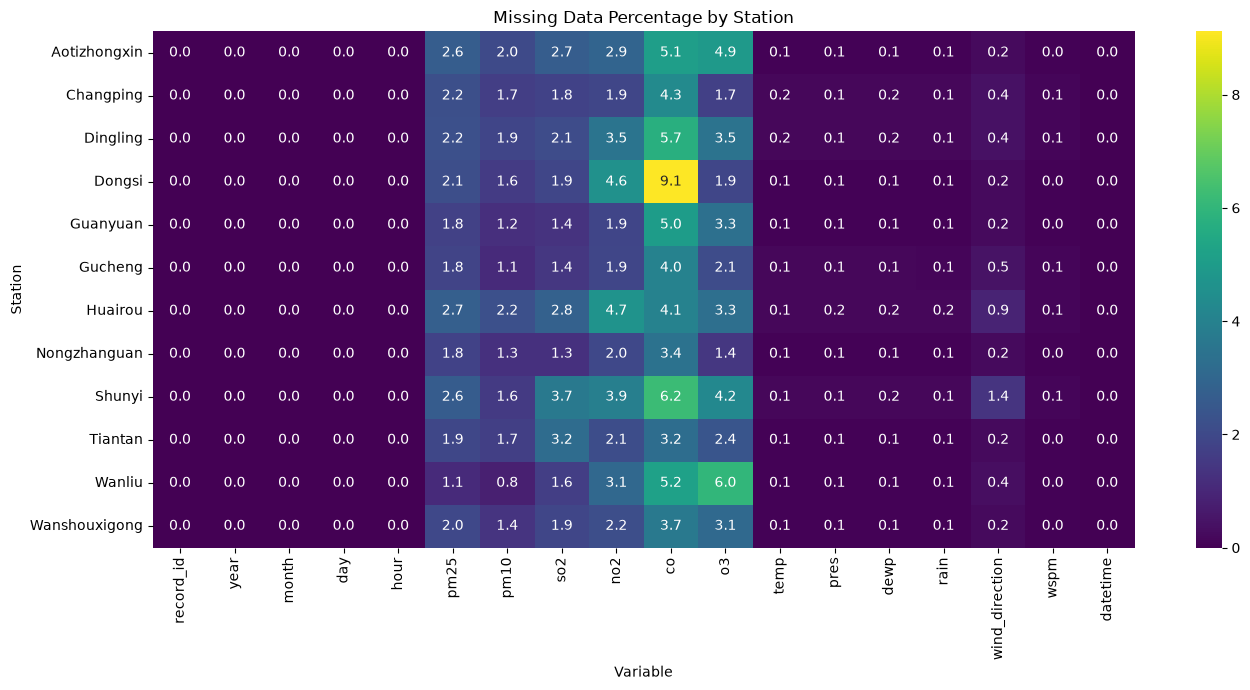

In [17]:
plt.figure(figsize=(14, 7))

sns.heatmap(
    missing_by_station,
    annot=True,
    fmt=".1f",
    cmap="viridis"
)

plt.title("Missing Data Percentage by Station")
plt.xlabel("Variable")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

#### Temporal Pattern of Missing Values

The overall missing percentage does not tell us whether missing values occur independently or in continuous blocks.

For sequential models, this distinction is important. For example:

- several isolated missing hours may be manageable through interpolation;
- a continuous missing period lasting several days may make that portion unsuitable for direct sequence construction.

We therefore visualize missingness in chronological order for individual stations.

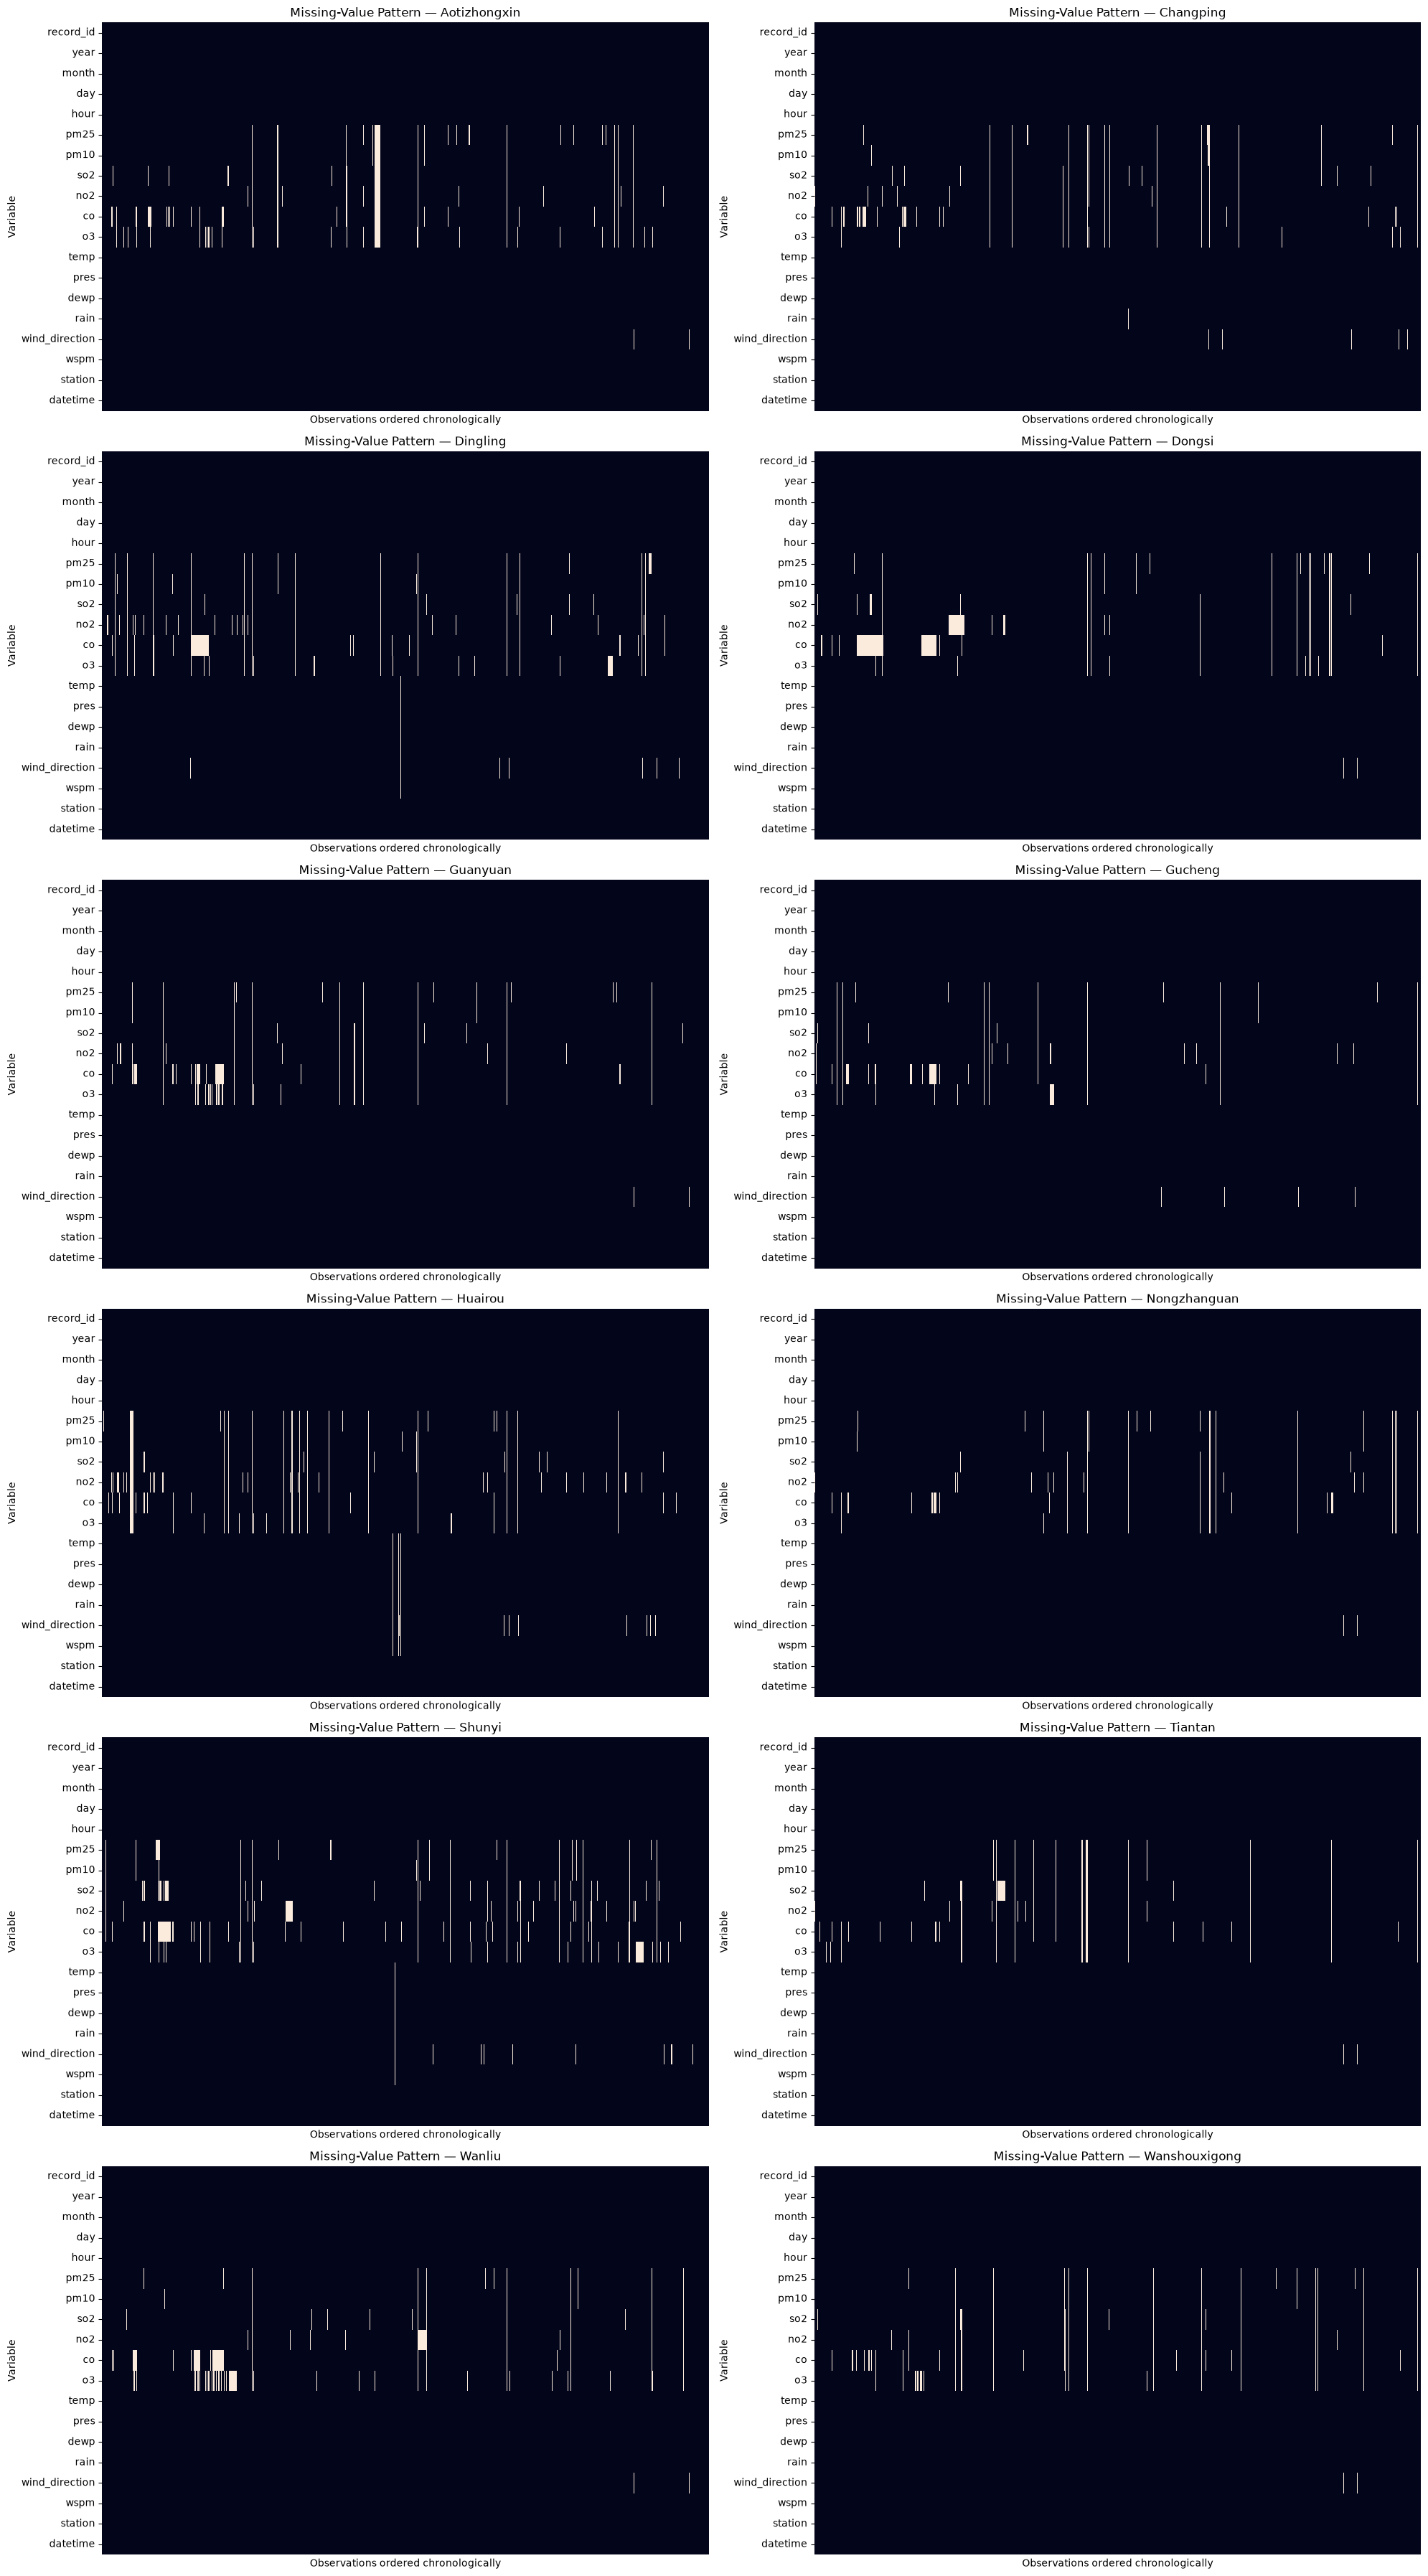

In [18]:
station_names = df["station"].unique()

n_stations = len(station_names)
n_cols = 2
n_rows = (n_stations + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 6 * n_rows)
)

axes = axes.flatten()

for i, station_name in enumerate(station_names):
    station_df = (
        df[df["station"] == station_name]
        .sort_values(["year", "month", "day", "hour"])
        .copy()
    )

    sns.heatmap(
        station_df.isna().T,
        ax=axes[i],
        cbar=False,
        yticklabels=True,
        xticklabels=False
    )

    axes[i].set_title(f"Missing-Value Pattern — {station_name}")
    axes[i].set_xlabel("Observations ordered chronologically")
    axes[i].set_ylabel("Variable")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


#### Checking Hourly Continuity

The dataset is intended to contain hourly observations. Before interpreting consecutive rows as consecutive hours, we verify the timestamp differences within each station.

This is important because two adjacent rows could otherwise be separated by more than one hour due to an existing gap in the recorded timestamps.

In [19]:
time_check = df.copy()

time_check["datetime"] = pd.to_datetime(
    time_check[["year", "month", "day", "hour"]]
)

time_check = time_check.sort_values(
    ["station", "datetime"]
)

time_check["time_difference"] = (
    time_check.groupby("station")["datetime"]
    .diff()
)

display(
    time_check["time_difference"]
    .value_counts()
    .head(10)
)

time_difference
0 days 01:00:00    420756
Name: count, dtype: int64

In [20]:
timestamp_gaps = time_check[
    time_check["time_difference"] > pd.Timedelta(hours=1)
]

print("Number of timestamp gaps > 1 hour:",
      len(timestamp_gaps))

display(
    timestamp_gaps[
        ["station", "datetime", "time_difference"]
    ].head(20)
)

Number of timestamp gaps > 1 hour: 0


,station,datetime,time_difference


In [21]:
expected_interval = pd.Timedelta(hours=1)

non_hourly = time_check[
    time_check["time_difference"].notna() &
    (time_check["time_difference"] != expected_interval)
]

print("Non-hourly intervals:", len(non_hourly))

Non-hourly intervals: 0



> All consecutive observations within each station are separated by exactly one hour.

#### Maximum consecutive missing hours

In [22]:
def max_consecutive_missing(series):
    """
    Return the maximum number of consecutive missing values
    in a pandas Series.
    """
    is_missing = series.isna()

    groups = is_missing.ne(is_missing.shift()).cumsum()

    missing_runs = (
        is_missing
        .groupby(groups)
        .sum()
    )

    return missing_runs.max()

In [23]:
variables = [
  "pm25",
  "pm10",
  "so2",
  "no2",
  "co",
  "o3",
  "temp",
  "pres",
  "dewp",
  "rain",
  "wind_direction",
  "wspm",
]


max_missing = (
    df.groupby("station")[variables]
       .agg(max_consecutive_missing)
)

display(max_missing)

,pm25,pm10,so2,no2,co,o3,temp,pres,dewp,rain,wind_direction,wspm
station,,,,,,,,,,,,
Aotizhongxin,343,343,343,343,343,343,6,6,6,6,5,5
Changping,167,144,64,64,175,64,6,6,6,6,5,5
Dingling,72,43,48,44,1051,262,6,6,6,6,5,5
Dongsi,58,57,57,900,1517,57,6,6,6,6,5,5
Guanyuan,71,44,103,103,441,103,6,6,6,6,5,5
Gucheng,54,25,61,66,349,260,7,7,7,6,7,5
Huairou,208,208,207,207,211,207,6,6,6,6,13,5
Nongzhanguan,56,55,55,55,147,55,6,6,6,6,5,5
Shunyi,197,38,95,423,749,497,6,6,6,6,6,5


> * Aotizhongxin has a maximum missing run of 343 hours for PM2.5 — about 14.3 days.
> * Dingling has a CO gap of 1,051 hours — about 43.8 days.
> * Dongsi has a CO gap of 1,517 hours — about 63.2 days.
> * Several stations have PM2.5 gaps exceeding 150–300 hours.
> * Meteorological variables have much shorter maximum gaps, mostly around 5–7 hours, with some larger wind-direction gaps.

The overall missing-value percentages show substantial differences between variables.

CO has the highest proportion of missing observations at approximately 4.92%, followed by O3 (3.16%), NO2 (2.88%), SO2 (2.14%), and PM2.5 (2.08%). PM10 has approximately 1.53% missing values.

The meteorological variables have considerably lower overall missingness, with TEMP, PRES, DEWP, RAIN, and WSPM each having less than 0.1% missing observations. Wind direction has approximately 0.43% missing values.

Although the overall percentage of missing PM2.5 observations is relatively low, the consecutive-missing analysis shows that missing values can occur in long continuous blocks. Therefore, overall missing percentage alone cannot be used to determine the appropriate missing-value treatment.

The temporal distribution and duration of missing sequences must be considered when preparing the data for sequential models.

#### Missing-Run Length Distribution

The maximum consecutive missing period shows the worst case, but it does not tell us how frequently gaps of different lengths occur.

Therefore, we examine the distribution of consecutive missing runs. This is particularly important for PM2.5 because it is the prediction target.

Since the dataset has continuous hourly timestamps within each station, a run of `n` consecutive missing rows corresponds to approximately `n` missing hours.

The distribution will help us distinguish:

- short gaps that may be suitable for interpolation,
- medium-length gaps that may require more careful treatment, and
- long gaps where interpolation would be unreliable and the data may need to be treated as a sequence boundary.

In [24]:
def missing_run_lengths(series):
    is_missing = series.isna()

    groups = is_missing.ne(is_missing.shift()).cumsum()

    run_lengths = (
        is_missing
        .groupby(groups)
        .sum()
    )

    return run_lengths[run_lengths > 0].astype(int).tolist()

In [25]:
pm25_runs = (
    df.groupby("station")["pm25"]
       .apply(missing_run_lengths)
       .explode()
       .astype(int)
       .rename("run_length")
       .reset_index()
)

display(pm25_runs.head())

,station,run_length
0,Aotizhongxin,1
1,Aotizhongxin,1
2,Aotizhongxin,1
3,Aotizhongxin,1
4,Aotizhongxin,1


In [26]:
run_distribution = (
    pm25_runs["run_length"]
    .value_counts()
    .sort_index()
    .rename_axis("missing_hours")
    .reset_index(name="number_of_runs")
)

display(run_distribution)

,missing_hours,number_of_runs
0,1,1653
1,2,662
2,3,159
3,4,97
4,5,53
5,6,30
6,7,23
7,8,14
8,9,7
9,10,9


In [27]:
run_bins = [0, 1, 3, 6, 24, 72, 168, float("inf")]
run_labels = [
    "1 hour",
    "2–3 hours",
    "4–6 hours",
    "7–24 hours",
    "25–72 hours",
    "73–168 hours",
    ">168 hours"
]

pm25_runs["run_category"] = pd.cut(
    pm25_runs["run_length"],
    bins=run_bins,
    labels=run_labels,
    right=True
)

run_category_summary = (
    pm25_runs["run_category"]
    .value_counts()
    .reindex(run_labels)
    .rename("number_of_runs")
    .to_frame()
)

run_category_summary["percentage"] = (
    run_category_summary["number_of_runs"]
    / run_category_summary["number_of_runs"].sum()
    * 100
)

display(run_category_summary)

,number_of_runs,percentage
run_category,,
1 hour,1653,58.266
2–3 hours,821,28.939
4–6 hours,180,6.345
7–24 hours,146,5.146
25–72 hours,31,1.093
73–168 hours,3,0.106
>168 hours,3,0.106


1. Short gaps (up to a few hours) are common and are candidates for interpolation.
2. Long gaps (>24 hours) are uncommon and should not be interpolated automatically.
3. The very long gaps should be treated as breaks in usable continuous sequences when we eventually construct training sequences.
4. We should still be careful with the 7–24 hour range, because filling an entire day of PM2.5 values could affect the temporal dynamics.

In [28]:
variables = [
    "pm25",
    "pm10",
    "so2",
    "no2",
    "co",
    "o3",
    "temp",
    "pres",
    "dewp",
    "rain",
    "wind_direction",
    "wspm"
]

all_missing_runs = []

for variable in variables:
    runs = (
        df.groupby("station")[variable]
           .apply(missing_run_lengths)
           .explode()
           .dropna()
           .astype(int)
    )

    for run_length in runs:
        all_missing_runs.append({
            "variable": variable,
            "run_length": run_length
        })

all_missing_runs = pd.DataFrame(all_missing_runs)

run_bins = [0, 1, 3, 6, 24, 72, 168, float("inf")]

run_labels = [
    "1 hour",
    "2–3 hours",
    "4–6 hours",
    "7–24 hours",
    "25–72 hours",
    "73–168 hours",
    ">168 hours"
]

all_missing_runs["run_category"] = pd.cut(
    all_missing_runs["run_length"],
    bins=run_bins,
    labels=run_labels,
    right=True
)

run_distribution = (
    all_missing_runs
    .groupby(["variable", "run_category"], observed=False)
    .size()
    .rename("number_of_runs")
    .reset_index()
)

display(run_distribution)

,variable,run_category,number_of_runs
0,co,1 hour,3160
1,co,2–3 hours,995
2,co,4–6 hours,265
3,co,7–24 hours,272
4,co,25–72 hours,46
...,...,...,...
79,wspm,4–6 hours,24
80,wspm,7–24 hours,0
81,wspm,25–72 hours,0
82,wspm,73–168 hours,0


In [29]:
run_distribution["percentage"] = (
    run_distribution["number_of_runs"]
    / run_distribution.groupby("variable")["number_of_runs"].transform("sum")
    * 100
)

display(run_distribution)

,variable,run_category,number_of_runs,percentage
0,co,1 hour,3160,66.289
1,co,2–3 hours,995,20.873
2,co,4–6 hours,265,5.559
3,co,7–24 hours,272,5.706
4,co,25–72 hours,46,0.965
...,...,...,...,...
79,wspm,4–6 hours,24,12.000
80,wspm,7–24 hours,0,0.000
81,wspm,25–72 hours,0,0.000
82,wspm,73–168 hours,0,0.000


In [30]:
run_distribution_pct = (
    run_distribution
    .pivot(
        index="variable",
        columns="run_category",
        values="percentage"
    )
    .fillna(0)
)

display(run_distribution_pct.round(2))

run_category,1 hour,2–3 hours,4–6 hours,7–24 hours,25–72 hours,73–168 hours,>168 hours
variable,,,,,,,
co,66.290,20.870,5.560,5.710,0.960,0.340,0.270
dewp,79.320,9.280,10.970,0.420,0.000,0.000,0.000
no2,67.750,20.890,5.050,5.020,0.990,0.160,0.130
o3,70.040,18.920,4.290,5.670,0.840,0.110,0.130
pm10,65.530,22.580,6.070,4.740,0.900,0.090,0.090
pm25,58.270,28.940,6.340,5.150,1.090,0.110,0.110
pres,79.570,9.790,10.210,0.430,0.000,0.000,0.000
rain,80.250,9.660,10.080,0.000,0.000,0.000,0.000
so2,65.110,22.870,5.020,5.410,1.230,0.250,0.110


In [31]:
max_run_comparison = (
    all_missing_runs
    .groupby("variable")["run_length"]
    .agg(
        max_missing_hours="max",
        median_missing_hours="median",
        total_missing_runs="count"
    )
    .sort_values("max_missing_hours", ascending=False)
)

display(max_run_comparison)

,max_missing_hours,median_missing_hours,total_missing_runs
variable,,,
co,1517,1.000,4767
no2,900,1.000,3743
o3,497,1.000,4550
so2,457,1.000,2846
pm25,343,1.000,2837
pm10,343,1.000,2321
wind_direction,13,1.000,1439
dewp,7,1.000,237
temp,7,1.000,234


**Missing-Data Findings and Preliminary Strategy**

The missing-run analysis shows that missing values are predominantly short-duration gaps. Across all variables, the median consecutive missing run is one hour. For PM2.5, approximately 93.5% of missing runs are six hours or shorter, while only a small fraction extend beyond 24 hours.

The meteorological variables exhibit even shorter missing runs. Their maximum consecutive gaps range from 5 to 13 hours, with virtually all missing runs occurring within six hours.

In contrast, several pollutant variables contain rare but extremely long missing periods. The maximum missing runs reach 343 hours for PM2.5 and PM10, 457 hours for SO2, 900 hours for NO2, and 1517 hours for CO.

Therefore, a single imputation strategy for all missing values would not be appropriate. Short gaps may be considered for interpolation, while long gaps should be preserved as missing and treated as boundaries when constructing continuous sequences for the forecasting model.

The exact interpolation threshold will be selected based on the requirements of sequence construction and validated during subsequent preprocessing.

#### Simultaneous Missingness Across Variables

Missing values in individual variables do not necessarily occur independently. Multiple variables may be missing at the same station and timestamp.

To understand the structure of missingness, we count how many variables are missing at each station-hour.

This helps distinguish isolated missing values from observations where several variables are unavailable simultaneously. Such periods are important for determining whether interpolation is appropriate and whether a timestamp can be used when constructing multivariate forecasting sequences.

In [32]:
variables = [
    "pm25",
    "pm10",
    "so2",
    "no2",
    "co",
    "o3",
    "temp",
    "pres",
    "dewp",
    "rain",
    "wind_direction",
    "wspm"
]

station_hour_missing = df.copy()

station_hour_missing["missing_count"] = (
    station_hour_missing[variables]
    .isna()
    .sum(axis=1)
)

display(
    station_hour_missing[
        ["station", "datetime", "missing_count"]
    ].head()
)

,station,datetime,missing_count
0,Aotizhongxin,2013-03-01 00:00:00,0
1,Aotizhongxin,2013-03-01 01:00:00,0
2,Aotizhongxin,2013-03-01 02:00:00,0
3,Aotizhongxin,2013-03-01 03:00:00,0
4,Aotizhongxin,2013-03-01 04:00:00,0


In [33]:
missing_count_distribution = (
    station_hour_missing["missing_count"]
    .value_counts()
    .sort_index()
    .rename_axis("number_of_missing_variables")
    .reset_index(name="number_of_station_hours")
)

missing_count_distribution["percentage"] = (
    missing_count_distribution["number_of_station_hours"]
    / len(station_hour_missing)
    * 100
)

display(missing_count_distribution)

,number_of_missing_variables,number_of_station_hours,percentage
0,0,382168,90.826
1,1,27203,6.465
2,2,4571,1.086
3,3,445,0.106
4,4,862,0.205
5,5,241,0.057
6,6,5252,1.248
7,7,26,0.006


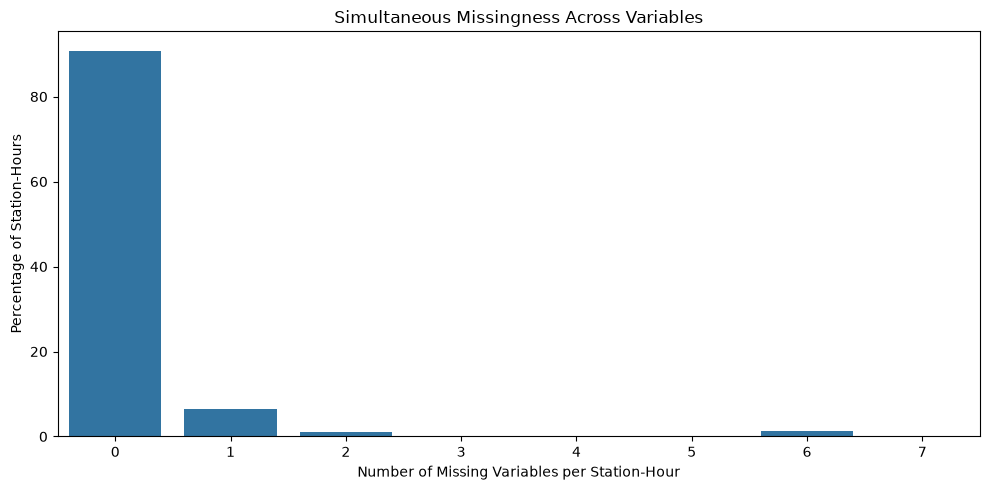

In [34]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=missing_count_distribution,
    x="number_of_missing_variables",
    y="percentage"
)

plt.title("Simultaneous Missingness Across Variables")
plt.xlabel("Number of Missing Variables per Station-Hour")
plt.ylabel("Percentage of Station-Hours")
plt.tight_layout()
plt.show()

**Simultaneous Missingness Findings**

Most station-hour observations are complete across the selected variables. Approximately 90.8% of station-hours have no missing values, while 6.5% have one missing variable and 1.1% have two missing variables.

A small number of station-hours contain several missing variables simultaneously. Notably, 1.25% of station-hours have six missing variables, while only 0.006% have seven missing variables.

This indicates that missing values are not always isolated to individual variables. Some missing observations affect multiple variables at the same station and hour.

Therefore, before selecting an imputation strategy, it is important to examine the relationships between missingness across variables. This will help determine whether missing values tend to occur independently or as part of larger data-availability events.

#### Missingness correlation

In [35]:
missing_indicators = df[variables].isna().astype(int)

missing_correlation = missing_indicators.corr()

display(missing_correlation)

,pm25,pm10,so2,no2,co,o3,temp,pres,dewp,rain,wind_direction,wspm
pm25,1.000,0.827,0.591,0.510,0.394,0.463,-0.004,-0.004,-0.005,-0.004,-0.003,-0.003
pm10,0.827,1.000,0.679,0.587,0.446,0.533,-0.003,-0.003,-0.003,-0.003,-0.001,-0.001
so2,0.591,0.679,1.000,0.566,0.495,0.518,-0.005,-0.005,-0.005,-0.005,-0.005,-0.004
no2,0.510,0.587,0.566,1.000,0.372,0.471,-0.005,-0.005,-0.005,-0.005,-0.006,-0.005
co,0.394,0.446,0.495,0.372,1.000,0.445,-0.006,-0.006,-0.006,-0.006,-0.008,-0.006
o3,0.463,0.533,0.518,0.471,0.445,1.000,-0.002,-0.002,-0.003,-0.002,0.001,-0.002
temp,-0.004,-0.003,-0.005,-0.005,-0.006,-0.002,1.000,0.989,0.994,0.975,0.371,0.883
pres,-0.004,-0.003,-0.005,-0.005,-0.006,-0.002,0.989,1.000,0.988,0.986,0.376,0.894
dewp,-0.005,-0.003,-0.005,-0.005,-0.006,-0.003,0.994,0.988,1.000,0.974,0.371,0.883
rain,-0.004,-0.003,-0.005,-0.005,-0.006,-0.002,0.975,0.986,0.974,1.000,0.369,0.883


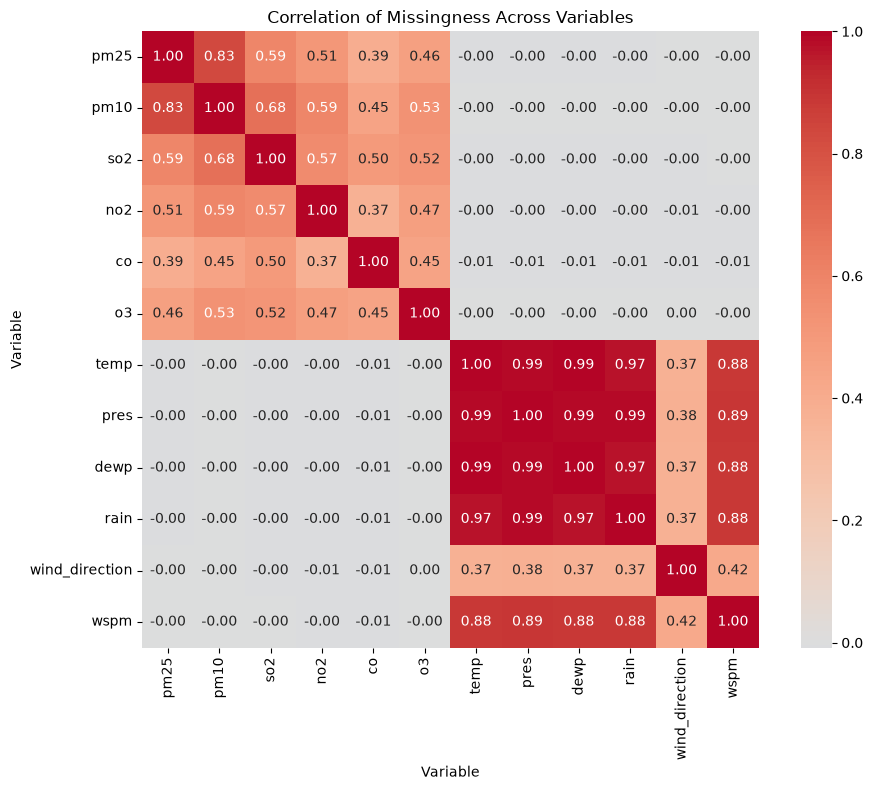

In [36]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    missing_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation of Missingness Across Variables")
plt.xlabel("Variable")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

**Missingness Correlation Findings**

The missingness correlation analysis shows clear relationships between groups of variables.

Among the pollutant variables, missingness is strongly correlated. The strongest relationship is between PM2.5 and PM10, with a missingness correlation of 0.827. Other pollutant pairs, including SO2, NO2, and O3, also show moderate to strong positive missingness correlations.

The meteorological variables form another group with strong missingness correlations. For example, temperature and dew point have a correlation of 0.994, while temperature and pressure have a correlation of 0.989.

In contrast, the missingness of pollutant variables has almost no correlation with the missingness of meteorological variables. For example, the correlation between PM2.5 missingness and temperature missingness is -0.004.

This suggests that missing values are not completely independent. They tend to occur in groups of related variables, particularly within pollutant measurements and within meteorological measurements.

Therefore, missing values should not be treated only as isolated individual observations. The preprocessing strategy should also consider periods where multiple variables are missing simultaneously, particularly when constructing continuous input sequences for PM2.5 forecasting.

#### Sequence Check

The forecasting model will use historical observations to predict PM2.5 for the next 24 hours. Therefore, missing-data availability should be evaluated at the sequence level rather than only at the individual observation level.

The forecast horizon is fixed at 24 hours, corresponding to the required predictions from t+1 through t+24.

Since the appropriate look-back window has not yet been determined, several candidate windows are considered: 24, 48, and 72 hours.

At this stage, no missing values are imputed. The purpose is to determine how many continuous forecasting windows are available in the original dataset and to assess how missing observations affect potential training sequences.

In [37]:
lookback_candidates = [24, 48, 72]
forecast_horizon = 24

print("Candidate look-back windows:", lookback_candidates)
print("Forecast horizon:", forecast_horizon)

Candidate look-back windows: [24, 48, 72]
Forecast horizon: 24


Because PM2.5 is the forecasting target, the first sequence-availability check focuses on the availability of PM2.5 itself.

A forecasting sample requires a continuous historical look-back followed by 24 consecutive future PM2.5 observations. At this stage, a sequence is considered target-available only when all 24 future PM2.5 values are present.

This provides a baseline estimate of how many forecasting targets are directly available before any imputation is performed.

In [38]:
def count_target_available_sequences(df, lookback, horizon):
    valid_sequences = 0
    total_sequences = 0

    for station, group in df.groupby("station"):
        group = group.sort_values("datetime").reset_index(drop=True)

        total_sequences += max(
            0,
            len(group) - lookback - horizon + 1
        )

        pm25 = group["pm25"]

        for start in range(len(group) - lookback - horizon + 1):
            target_start = start + lookback
            target_end = target_start + horizon

            target = pm25.iloc[target_start:target_end]

            if target.notna().all():
                valid_sequences += 1

    return total_sequences, valid_sequences

In [39]:
sequence_results = []

for lookback in lookback_candidates:
    total, valid = count_target_available_sequences(
        df,
        lookback,
        forecast_horizon
    )

    sequence_results.append({
        "lookback_hours": lookback,
        "total_possible_sequences": total,
        "target_available_sequences": valid,
        "percentage_available": 100 * valid / total
    })

sequence_availability = pd.DataFrame(sequence_results)

display(sequence_availability)

,lookback_hours,total_possible_sequences,target_available_sequences,percentage_available
0,24,420204,362515,86.271
1,48,419916,362227,86.262
2,72,419628,361943,86.253


**Historical completeness for PM2.5**

In [40]:
def count_pm25_complete_sequences(df, lookback, horizon):
    valid_sequences = 0
    total_sequences = 0

    for station, group in df.groupby("station"):
        group = group.sort_values("datetime").reset_index(drop=True)

        n_sequences = len(group) - lookback - horizon + 1

        if n_sequences <= 0:
            continue

        total_sequences += n_sequences

        pm25 = group["pm25"]

        for start in range(n_sequences):
            input_start = start
            input_end = start + lookback

            target_start = input_end
            target_end = target_start + horizon

            input_values = pm25.iloc[input_start:input_end]
            target_values = pm25.iloc[target_start:target_end]

            if input_values.notna().all() and target_values.notna().all():
                valid_sequences += 1

    return total_sequences, valid_sequences

In [41]:
pm25_sequence_results = []

for lookback in lookback_candidates:
    total, valid = count_pm25_complete_sequences(
        df,
        lookback,
        forecast_horizon
    )

    pm25_sequence_results.append({
        "lookback_hours": lookback,
        "total_possible_sequences": total,
        "complete_pm25_sequences": valid,
        "percentage_available": 100 * valid / total
    })

pm25_sequence_availability = pd.DataFrame(pm25_sequence_results)

display(pm25_sequence_availability)

,lookback_hours,total_possible_sequences,complete_pm25_sequences,percentage_available
0,24,420204,322260,76.691
1,48,419916,287042,68.357
2,72,419628,255878,60.977


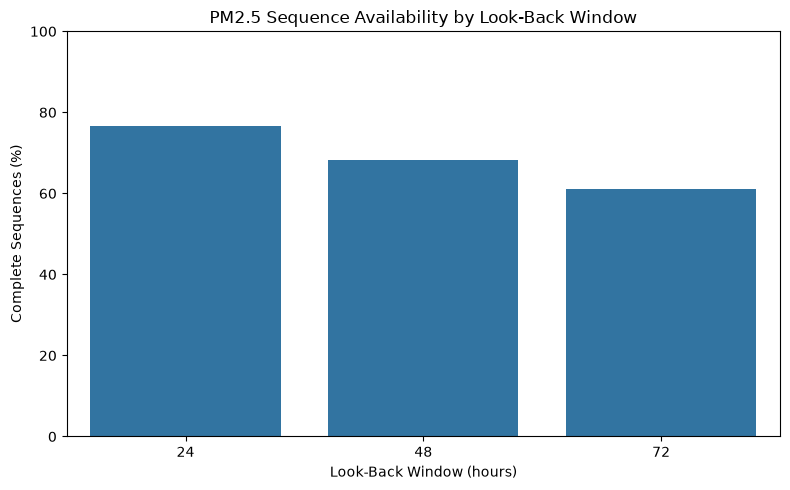

In [42]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=pm25_sequence_availability,
    x="lookback_hours",
    y="percentage_available"
)

plt.title("PM2.5 Sequence Availability by Look-Back Window")
plt.xlabel("Look-Back Window (hours)")
plt.ylabel("Complete Sequences (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

**All variable completeness**

In [43]:
def count_complete_multivariate_sequences(
    df,
    variables,
    lookback,
    horizon
):
    valid_sequences = 0
    total_sequences = 0

    for station, group in df.groupby("station"):
        group = group.sort_values("datetime").reset_index(drop=True)

        n = len(group)
        n_sequences = n - lookback - horizon + 1

        if n_sequences <= 0:
            continue

        total_sequences += n_sequences

        # True where all input variables are present
        input_complete = group[variables].notna().all(axis=1).to_numpy()

        # True where target PM2.5 is present
        target_complete = group["pm25"].notna().to_numpy()

        # Prefix sums let us check whether an entire window
        # contains missing values in O(1) per sequence.
        input_missing = (~input_complete).astype(np.int64)
        target_missing = (~target_complete).astype(np.int64)

        input_prefix = np.concatenate([[0], np.cumsum(input_missing)])
        target_prefix = np.concatenate([[0], np.cumsum(target_missing)])

        # Input window: [start, start + lookback)
        input_missing_count = (
            input_prefix[lookback:lookback + n_sequences]
            - input_prefix[:n_sequences]
        )

        # Target window: [start + lookback, start + lookback + horizon)
        target_start = lookback

        target_missing_count = (
            target_prefix[target_start + horizon:
                          target_start + horizon + n_sequences]
            - target_prefix[target_start:
                            target_start + n_sequences]
        )

        valid_sequences += np.sum(
            (input_missing_count == 0) &
            (target_missing_count == 0)
        )

    return total_sequences, int(valid_sequences)


In [44]:
multivariate_results = []

for lookback in lookback_candidates:
    total, valid = count_complete_multivariate_sequences(
        df,
        variables,
        lookback,
        forecast_horizon
    )

    multivariate_results.append({
        "lookback_hours": lookback,
        "total_possible_sequences": total,
        "complete_sequences": valid,
        "percentage_available": 100 * valid / total
    })

multivariate_availability = pd.DataFrame(multivariate_results)

display(multivariate_availability)

,lookback_hours,total_possible_sequences,complete_sequences,percentage_available
0,24,420204,211763,50.395
1,48,419916,139119,33.130
2,72,419628,101246,24.128


pm2.5 missingness correlation across stations

In [45]:
pm25_missing_by_station = (
    df
    .pivot(
        index="datetime",
        columns="station",
        values="pm25"
    )
    .isna()
    .astype(int)
)

pm25_station_missing_corr = pm25_missing_by_station.corr()

display(pm25_station_missing_corr.round(3))

station,Aotizhongxin,Changping,Dingling,Dongsi,Guanyuan,Gucheng,Huairou,Nongzhanguan,Shunyi,Tiantan,Wanliu,Wanshouxigong
station,,,,,,,,,,,,
Aotizhongxin,1.000,0.187,0.097,0.132,0.139,0.142,0.099,0.143,0.089,0.120,0.185,0.137
Changping,0.187,1.000,0.125,0.115,0.134,0.131,0.113,0.211,0.111,0.126,0.199,0.146
Dingling,0.097,0.125,1.000,0.117,0.127,0.130,0.122,0.143,0.111,0.121,0.159,0.139
Dongsi,0.132,0.115,0.117,1.000,0.189,0.138,0.111,0.163,0.116,0.153,0.182,0.168
Guanyuan,0.139,0.134,0.127,0.189,1.000,0.153,0.171,0.175,0.117,0.156,0.201,0.149
Gucheng,0.142,0.131,0.130,0.138,0.153,1.000,0.127,0.153,0.137,0.164,0.214,0.171
Huairou,0.099,0.113,0.122,0.111,0.171,0.127,1.000,0.132,0.105,0.127,0.155,0.108
Nongzhanguan,0.143,0.211,0.143,0.163,0.175,0.153,0.132,1.000,0.132,0.167,0.191,0.170
Shunyi,0.089,0.111,0.111,0.116,0.117,0.137,0.105,0.132,1.000,0.131,0.157,0.132


In [46]:
pm25_missing_by_station["missing_station_count"] = (
    pm25_missing_by_station.sum(axis=1)
)

station_missing_distribution = (
    pm25_missing_by_station["missing_station_count"]
    .value_counts()
    .sort_index()
    .rename_axis("number_of_stations_missing_pm25")
    .reset_index(name="number_of_timestamps")
)

station_missing_distribution["percentage"] = (
    station_missing_distribution["number_of_timestamps"]
    / len(pm25_missing_by_station)
    * 100
)

display(station_missing_distribution)

,number_of_stations_missing_pm25,number_of_timestamps,percentage
0,0,28663,81.745
1,1,5227,14.907
2,2,906,2.584
3,3,120,0.342
4,4,40,0.114
5,5,8,0.023
6,6,7,0.020
7,8,2,0.006
8,11,10,0.029
9,12,81,0.231


#### Short-Gap Interpolation Sensitivity Analysis

The missing-data analysis showed that most missing runs are short, but several variables also contain rare long gaps. Therefore, rather than selecting an interpolation threshold arbitrarily, we compare three preprocessing scenarios:

1. No interpolation
2. Interpolation of gaps up to 3 consecutive hours
3. Interpolation of gaps up to 6 consecutive hours

Interpolation is performed independently within each station and variable using temporal information only. Missing values are not filled using measurements from other stations.

The 24-hour PM2.5 forecast targets are kept as observed values. In other words, interpolated PM2.5 values are not used as ground-truth targets for the forecasting task.

The purpose of this analysis is to determine how each interpolation strategy affects the number of usable multivariate forecasting sequences.

In [47]:
interpolation_variables = [
    "pm25", "pm10", "so2", "no2", "co", "o3",
    "temp", "pres", "dewp", "rain", "wspm", "wind_direction"
]

lookback_candidates = [24, 48, 72]
forecast_horizon = 24

interpolation_limits = {
    "No interpolation": 0,
    "1–3 hour interpolation": 3,
    "1–6 hour interpolation": 6
}

In [48]:
def interpolate_short_gaps(df, limit):
    """
    Interpolate short internal gaps within each station.

    Interpolation is performed only for numeric continuous variables.
    wind_direction is categorical and is left unchanged.
    """

    result = df.sort_values(["station", "datetime"]).copy()

    if limit == 0:
        return result

    numeric_variables = [
        "pm25", "pm10", "so2", "no2", "co", "o3",
        "temp", "pres", "dewp", "rain", "wspm"
    ]

    for variable in numeric_variables:
        result[variable] = (
            result.groupby("station")[variable]
            .transform(
                lambda s: s.interpolate(
                    method="linear",
                    limit=limit,
                    limit_area="inside"
                )
            )
        )

    return result

In [49]:
interpolation_results = []

for strategy, limit in interpolation_limits.items():
    interpolated = interpolate_short_gaps(df, limit)

    for variable in variables:
        original_missing = df[variable].isna()
        remaining_missing = interpolated[variable].isna()

        filled = (
            original_missing &
            ~remaining_missing
        ).sum()

        interpolation_results.append({
            "strategy": strategy,
            "variable": variable,
            "values_interpolated": filled
        })

interpolation_summary = pd.DataFrame(interpolation_results)

display(
    interpolation_summary.pivot(
        index="variable",
        columns="strategy",
        values="values_interpolated"
    )
)

strategy,1–3 hour interpolation,1–6 hour interpolation,No interpolation
variable,,,
co,7200,8710,0
dewp,323,402,0
no2,5540,6583,0
o3,6575,7840,0
pm10,3515,4155,0
pm25,4543,5385,0
pres,317,392,0
rain,318,390,0
so2,4291,5125,0


In [50]:
def count_complete_sequences(
    df,
    input_variables,
    lookback,
    horizon
):
    total_sequences = 0
    valid_sequences = 0

    for station, group in df.groupby("station"):
        group = (
            group
            .sort_values("datetime")
            .reset_index(drop=True)
        )

        n = len(group)
        n_sequences = n - lookback - horizon + 1

        if n_sequences <= 0:
            continue

        total_sequences += n_sequences

        # Whether every input variable is available at each timestep
        input_complete = (
            group[input_variables]
            .notna()
            .all(axis=1)
            .to_numpy()
        )

        # Whether PM2.5 target is available
        target_complete = (
            group["pm25"]
            .notna()
            .to_numpy()
        )

        # Number of missing input observations in each look-back window
        input_missing = (~input_complete).astype(int)

        cumulative_missing = np.concatenate(
            [[0], np.cumsum(input_missing)]
        )

        input_window_missing = (
            cumulative_missing[lookback:]
            - cumulative_missing[:-lookback]
        )

        input_window_complete = (
            input_window_missing == 0
        )

        # Number of missing PM2.5 observations
        # in each future 24-hour target window
        target_missing = (~target_complete).astype(int)

        cumulative_target_missing = np.concatenate(
            [[0], np.cumsum(target_missing)]
        )

        target_window_missing = (
            cumulative_target_missing[horizon:]
            - cumulative_target_missing[:-horizon]
        )

        target_window_complete = (
            target_window_missing == 0
        )

        # Align:
        # input window starts at t
        # target window starts at t + lookback
        usable = (
            input_window_complete[:n_sequences]
            &
            target_window_complete[lookback:lookback + n_sequences]
        )

        valid_sequences += usable.sum()

    return total_sequences, int(valid_sequences)

In [51]:
sequence_results = []

for strategy, limit in interpolation_limits.items():

    print(f"Processing: {strategy}")

    processed = interpolate_short_gaps(df, limit)

    for lookback in lookback_candidates:

        total, valid = count_complete_sequences(
            processed,
            interpolation_variables,
            lookback,
            forecast_horizon
        )

        percentage = (
            valid / total * 100
            if total > 0 else 0
        )

        sequence_results.append({
            "interpolation_strategy": strategy,
            "lookback": lookback,
            "total_possible_sequences": total,
            "complete_sequences": valid,
            "percentage": percentage
        })

sequence_results = pd.DataFrame(sequence_results)

display(sequence_results)

Processing: No interpolation
Processing: 1–3 hour interpolation
Processing: 1–6 hour interpolation


,interpolation_strategy,lookback,total_possible_sequences,complete_sequences,percentage
0,No interpolation,24,420204,211763,50.395
1,No interpolation,48,419916,139119,33.130
2,No interpolation,72,419628,101246,24.128
3,1–3 hour interpolation,24,420204,346002,82.341
4,1–3 hour interpolation,48,419916,314736,74.952
5,1–3 hour interpolation,72,419628,288870,68.840
6,1–6 hour interpolation,24,420204,359565,85.569
7,1–6 hour interpolation,48,419916,333632,79.452
8,1–6 hour interpolation,72,419628,312279,74.418


In [52]:
sequence_comparison = (
    sequence_results
    .pivot(
        index="interpolation_strategy",
        columns="lookback",
        values="percentage"
    )
)

display(sequence_comparison.round(2))

lookback,24,48,72
interpolation_strategy,,,
1–3 hour interpolation,82.340,74.950,68.840
1–6 hour interpolation,85.570,79.450,74.420
No interpolation,50.400,33.130,24.130


In [53]:
baseline = (
    sequence_results[
        sequence_results["interpolation_strategy"]
        == "No interpolation"
    ][
        ["lookback", "complete_sequences"]
    ]
    .rename(columns={
        "complete_sequences": "baseline_sequences"
    })
)

sequence_results_with_gain = sequence_results.merge(
    baseline,
    on="lookback"
)

sequence_results_with_gain["additional_sequences"] = (
    sequence_results_with_gain["complete_sequences"]
    - sequence_results_with_gain["baseline_sequences"]
)

display(sequence_results_with_gain)

,interpolation_strategy,lookback,total_possible_sequences,complete_sequences,percentage,baseline_sequences,additional_sequences
0,No interpolation,24,420204,211763,50.395,211763,0
1,No interpolation,48,419916,139119,33.130,139119,0
2,No interpolation,72,419628,101246,24.128,101246,0
3,1–3 hour interpolation,24,420204,346002,82.341,211763,134239
4,1–3 hour interpolation,48,419916,314736,74.952,139119,175617
5,1–3 hour interpolation,72,419628,288870,68.840,101246,187624
6,1–6 hour interpolation,24,420204,359565,85.569,211763,147802
7,1–6 hour interpolation,48,419916,333632,79.452,139119,194513
8,1–6 hour interpolation,72,419628,312279,74.418,101246,211033


**Interpolation Sensitivity Results**

Three preprocessing scenarios were compared to evaluate the effect of short-gap interpolation on the availability of complete forecasting sequences: no interpolation, interpolation of gaps up to 3 hours, and interpolation of gaps up to 6 hours.

For each scenario, a sequence was considered complete when all candidate input variables were available throughout the look-back period and all 24 future PM2.5 target values were observed. Interpolation was applied only within the same station and only to continuous numeric variables. The categorical `wind_direction` variable was not interpolated.

Without interpolation, the proportion of complete multivariate sequences decreased substantially as the look-back increased, from 50.4% for a 24-hour look-back to 24.1% for a 72-hour look-back.

Allowing interpolation of gaps up to 3 hours increased sequence availability to 82.3%, 75.0%, and 68.8% for 24-, 48-, and 72-hour look-backs respectively.

Extending the interpolation limit to 6 hours provided a further increase, reaching 85.6%, 79.5%, and 74.4% respectively. However, the additional gain from extending the threshold from 3 to 6 hours was smaller than the gain obtained from interpolating the first 3 hours.

These results indicate that short-gap interpolation can substantially increase the number of usable forecasting sequences. However, sequence availability alone does not determine the final interpolation threshold. The potential effect of interpolation on the quality of the reconstructed values should also be considered before selecting the final preprocessing strategy.

## Temporal Dynamics and Seasonality

The objective of this phase is to understand the temporal behavior of PM2.5 before constructing the sequence model.

The analysis focuses on two aspects:

1. **Temporal dependence:** how strongly current PM2.5 is related to previous observations. ACF and PACF will be used to examine this relationship across different time lags.
2. **Seasonal patterns:** how PM2.5 varies according to hour of day, day of week, and month of year.

The temporal dependence analysis will provide evidence for selecting candidate look-back windows for the sequence model. The seasonal analysis will help determine whether explicit temporal features, such as cyclical hour or month representations, may be useful as model inputs.

The analysis will be performed on PM2.5 because it is the forecasting target. Station-level differences will be considered where appropriate.

#### Temporal dependence of PM2.5

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

station_name = "Aotizhongxin"

station_pm25 = (
    df[df["station"] == station_name]
    .sort_values("datetime")
    .set_index("datetime")["pm25"]
)

print("Station:", station_name)
print("Observations:", len(station_pm25))
print("Missing PM2.5:", station_pm25.isna().sum())

Station: Aotizhongxin
Observations: 35064
Missing PM2.5: 925


In [55]:
def get_continuous_segments(series):
    """
    Split a time series into continuous hourly segments
    containing no missing values.
    """

    series = series.sort_index()

    # A break occurs when:
    # 1. PM2.5 is missing
    # 2. The timestamp is not exactly one hour after the previous timestamp
    time_gap = series.index.to_series().diff()

    breaks = (
        series.isna()
        | time_gap.ne(pd.Timedelta(hours=1))
    )

    segment_id = breaks.cumsum()

    segments = []

    for _, segment in series.groupby(segment_id):
        segment = segment.dropna()

        if len(segment) > 0:
            segments.append(segment)

    return segments

In [56]:
segments = get_continuous_segments(station_pm25)

segment_lengths = pd.Series(
    [len(segment) for segment in segments]
)

print("Number of continuous segments:", len(segments))
print("Longest segment:", segment_lengths.max(), "hours")
print("Median segment length:", segment_lengths.median(), "hours")

Number of continuous segments: 210
Longest segment: 1509 hours
Median segment length: 84.0 hours


In [57]:
segment_lengths.sort_values(ascending=False).head(10)

0      1509
23     1407
5      1378
6       915
11      857
42      820
197     794
10      719
198     691
109     600
dtype: int64

In [58]:
longest_segment = segments[
    np.argmax([len(segment) for segment in segments])
]

print("Selected segment length:", len(longest_segment))

Selected segment length: 1509


In [59]:
from statsmodels.tsa.stattools import acf

max_lag = 168  # 7 days

acf_values = acf(
    longest_segment,
    nlags=max_lag,
    fft=True
)

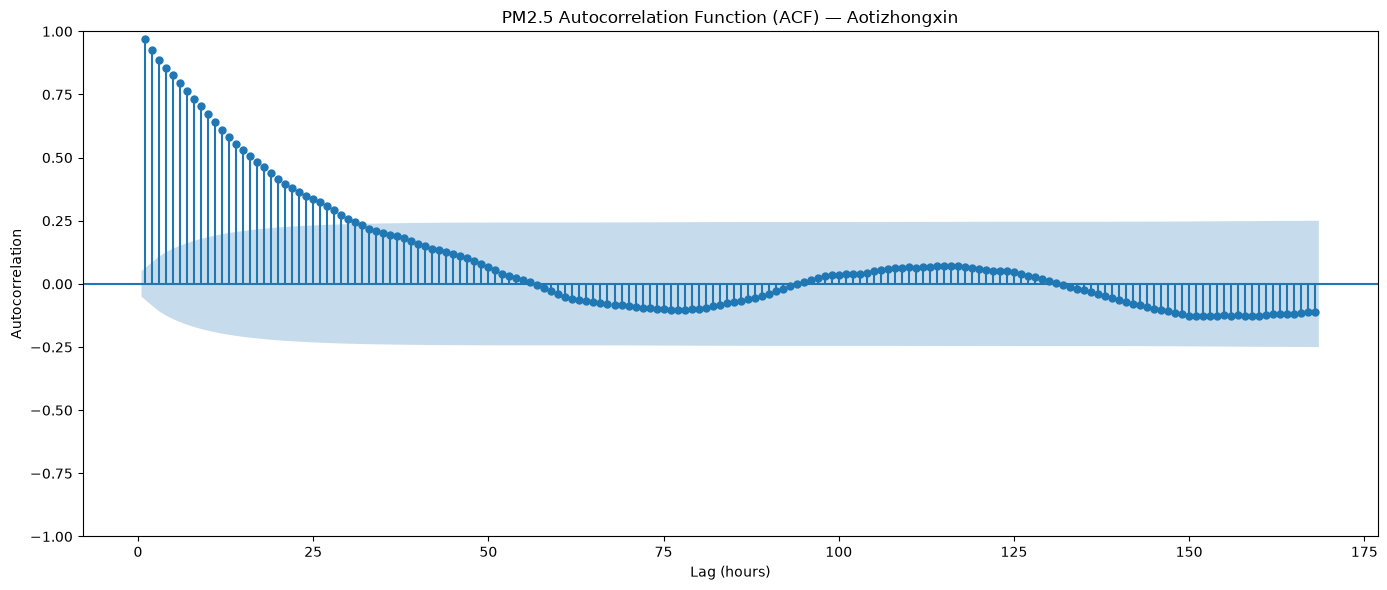

In [60]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(14, 6))

plot_acf(
    longest_segment,
    lags=max_lag,
    ax=plt.gca(),
    zero=False
)

plt.title(
    f"PM2.5 Autocorrelation Function (ACF) — {station_name}"
)
plt.xlabel("Lag (hours)")
plt.ylabel("Autocorrelation")

plt.tight_layout()
plt.show()

PACF

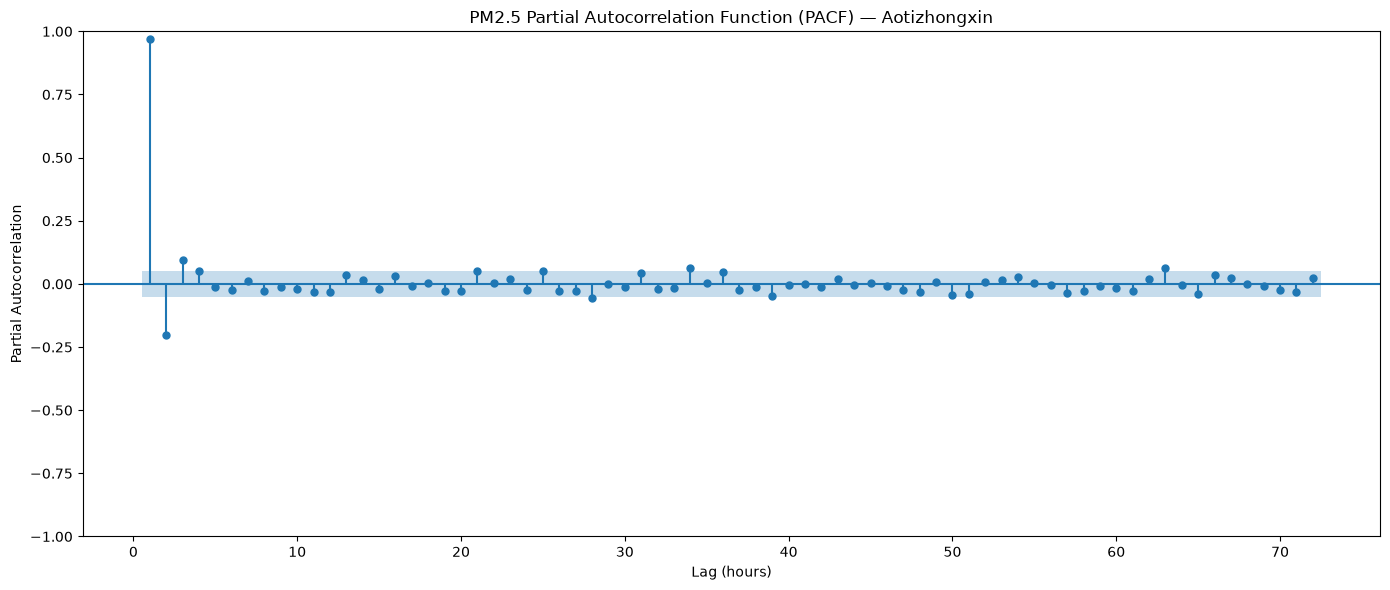

In [61]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(14, 6))

plot_pacf(
    longest_segment,
    lags=72,
    ax=plt.gca(),
    zero=False,
    method="ywm"
)

plt.title(
    f"PM2.5 Partial Autocorrelation Function (PACF) — {station_name}"
)
plt.xlabel("Lag (hours)")
plt.ylabel("Partial Autocorrelation")

plt.tight_layout()
plt.show()

In [62]:
from statsmodels.tsa.stattools import acf, pacf

acf_lags = [1, 6, 12, 24, 48, 72]
pacf_lags = [1, 2, 3, 24, 48, 72]

temporal_results = []

for station_name, group in df.groupby("station"):

    station_pm25 = (
        group
        .sort_values("datetime")
        .set_index("datetime")["pm25"]
    )

    segments = get_continuous_segments(station_pm25)

    # Use the longest continuous observed segment
    longest_segment = max(segments, key=len)

    acf_values = acf(
        longest_segment,
        nlags=max(acf_lags),
        fft=True
    )

    pacf_values = pacf(
        longest_segment,
        nlags=max(pacf_lags),
        method="ywm"
    )

    result = {"station": station_name}

    for lag in acf_lags:
        result[f"ACF_{lag}h"] = acf_values[lag]

    for lag in pacf_lags:
        result[f"PACF_{lag}h"] = pacf_values[lag]

    temporal_results.append(result)

temporal_summary = pd.DataFrame(temporal_results)

display(
    temporal_summary.round(3)
)

,station,ACF_1h,ACF_6h,ACF_12h,ACF_24h,ACF_48h,ACF_72h,PACF_1h,PACF_2h,PACF_3h,PACF_24h,PACF_48h,PACF_72h
0,Aotizhongxin,0.969,0.794,0.609,0.349,0.090,-0.093,0.969,-0.204,0.093,-0.024,-0.031,0.024
1,Changping,0.965,0.754,0.575,0.383,0.023,-0.102,0.965,-0.187,0.043,-0.025,-0.025,-0.029
2,Dingling,0.961,0.776,0.600,0.392,-0.044,-0.154,0.961,-0.042,0.018,-0.023,-0.027,-0.001
3,Dongsi,0.965,0.771,0.642,0.498,0.103,-0.193,0.965,-0.146,-0.004,-0.002,0.011,-0.024
4,Guanyuan,0.957,0.723,0.548,0.346,0.020,-0.175,0.957,-0.194,0.054,0.021,-0.006,-0.027
5,Gucheng,0.966,0.675,0.440,0.278,0.061,-0.022,0.966,-0.332,0.018,-0.044,-0.045,-0.035
6,Huairou,0.939,0.637,0.369,0.172,-0.029,-0.129,0.939,-0.097,-0.043,-0.051,-0.028,0.011
7,Nongzhanguan,0.961,0.744,0.555,0.302,0.087,-0.088,0.961,-0.227,0.039,-0.020,-0.006,-0.014
8,Shunyi,0.954,0.772,0.564,0.334,-0.063,-0.042,0.954,0.141,-0.037,-0.045,-0.003,-0.000
9,Tiantan,0.969,0.718,0.464,0.254,-0.001,-0.043,0.969,-0.289,-0.002,-0.041,-0.012,-0.004


**ACF/PACF Findings Across Stations**

The ACF and PACF analysis was repeated across all 12 monitoring stations to determine whether the temporal dependence observed at a single station was representative of the wider dataset.

PM2.5 shows very strong short-term persistence across all stations. The one-hour ACF ranges from 0.939 to 0.969, while the six-hour ACF remains between 0.637 and 0.794. The autocorrelation gradually decreases with increasing lag but remains positive at 24 hours for every station, with values ranging from 0.172 to 0.498.

By 48 hours, the ACF is close to zero for most stations, ranging from -0.063 to 0.103. At 72 hours, the ACF is generally weak and negative. This indicates that PM2.5 has strong short-term temporal persistence and retains meaningful dependence over approximately one day, while direct persistence over two to three days is considerably weaker.

The PACF shows a similar pattern. The first lag has very strong partial autocorrelation across all stations, ranging from 0.939 to 0.969. Most of the remaining direct dependence is concentrated in the first few hours, while PACF values at 24, 48, and 72 hours are close to zero.

These results provide stronger statistical support for shorter look-back windows, particularly a 24-hour history. However, 48- and 72-hour windows are retained as candidate look-back values because the final forecasting model will use multiple pollutant and meteorological variables rather than PM2.5 alone. Their usefulness should therefore be determined through model validation rather than ACF/PACF alone.

#### Seasonal Structure
* Average PM2.5 by hour of day
* Average PM2.5 by day of week
* Average PM2.5 by month

##### Hour-of-day patterns.

In [63]:
hourly_pm25 = (
    df.groupby("hour")["pm25"]
       .agg(["mean", "median", "std", "count"])
       .reset_index()
)

display(hourly_pm25.round(2))

,hour,mean,median,std,count
0,0,87.590,62.000,86.600,17262
1,1,86.560,61.000,87.650,17252
2,2,84.520,60.000,86.090,17248
3,3,82.010,58.000,82.870,17204
4,4,79.300,57.000,79.770,17233
5,5,76.400,54.000,77.210,17239
6,6,74.240,53.000,75.490,17256
7,7,73.270,52.000,73.360,17231
8,8,74.530,53.000,72.600,17256
9,9,76.060,54.000,73.020,17233


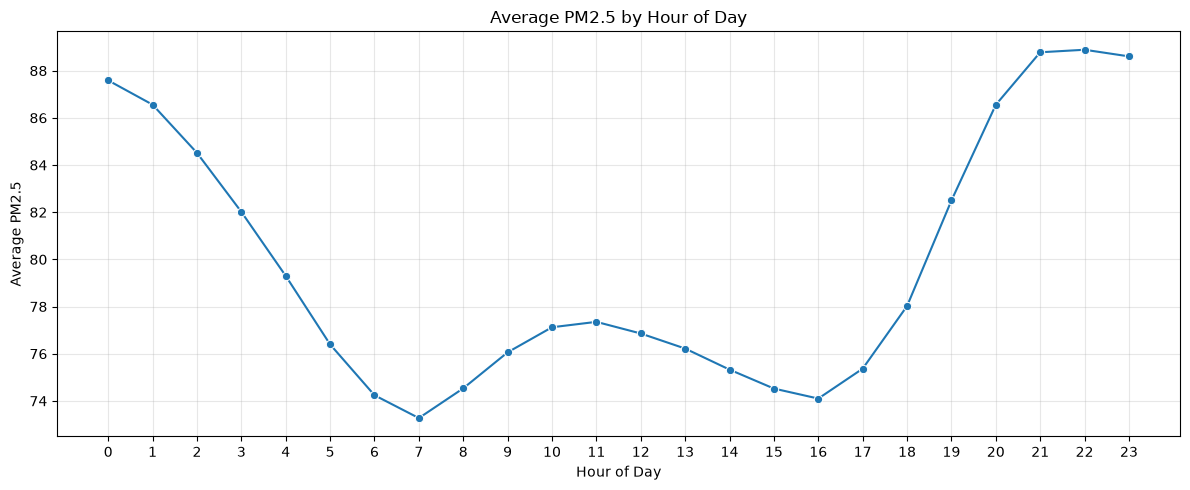

In [64]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=hourly_pm25,
    x="hour",
    y="mean",
    marker="o"
)

plt.title("Average PM2.5 by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average PM2.5")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [68]:
hourly_station_pm25 = (
    df.groupby(["station", "hour"])["pm25"]
       .mean()
       .reset_index()
)

display(hourly_station_pm25.round(2))

,station,hour,pm25
0,Aotizhongxin,0,92.300
1,Aotizhongxin,1,92.070
2,Aotizhongxin,2,91.690
3,Aotizhongxin,3,88.740
4,Aotizhongxin,4,85.340
...,...,...,...
283,Wanshouxigong,19,87.400
284,Wanshouxigong,20,92.580
285,Wanshouxigong,21,95.730
286,Wanshouxigong,22,95.310


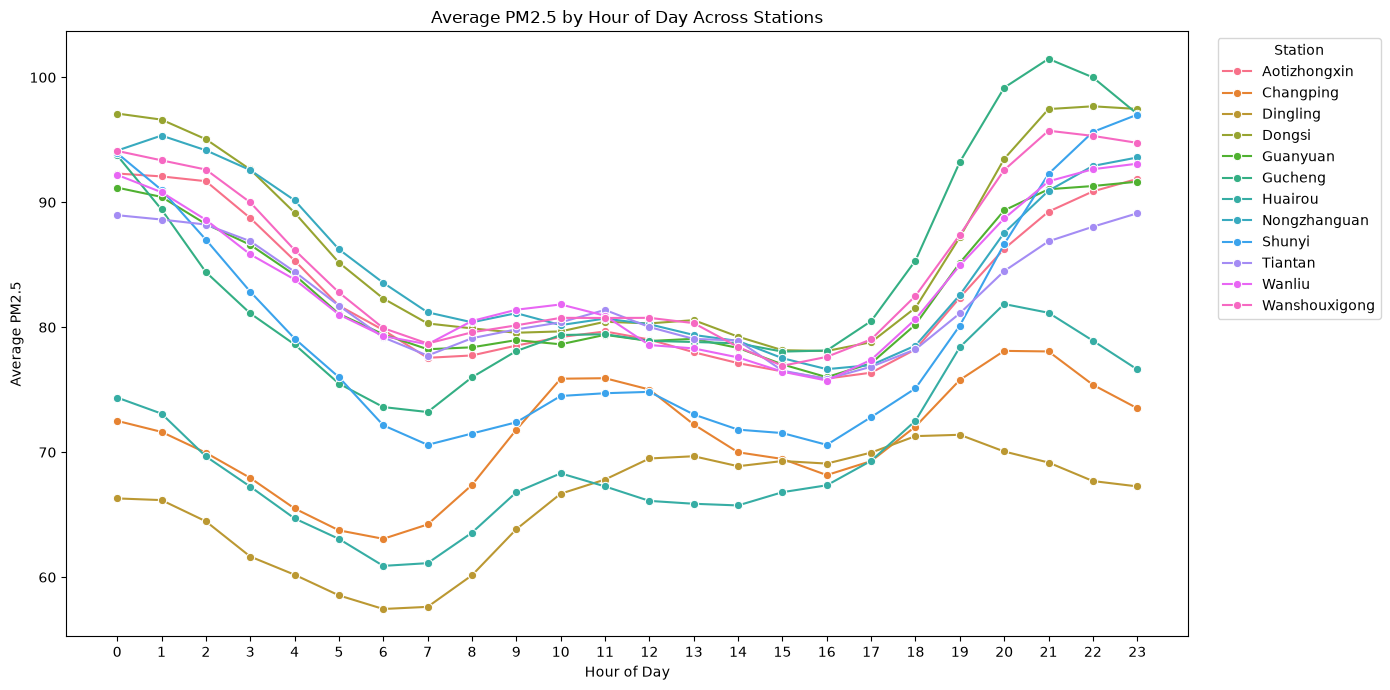

In [69]:
plt.figure(figsize=(14, 7))

sns.lineplot(
    data=hourly_station_pm25,
    x="hour",
    y="pm25",
    hue="station",
    marker="o"
)

plt.title("Average PM2.5 by Hour of Day Across Stations")
plt.xlabel("Hour of Day")
plt.ylabel("Average PM2.5")
plt.xticks(range(24))
plt.legend(
    title="Station",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

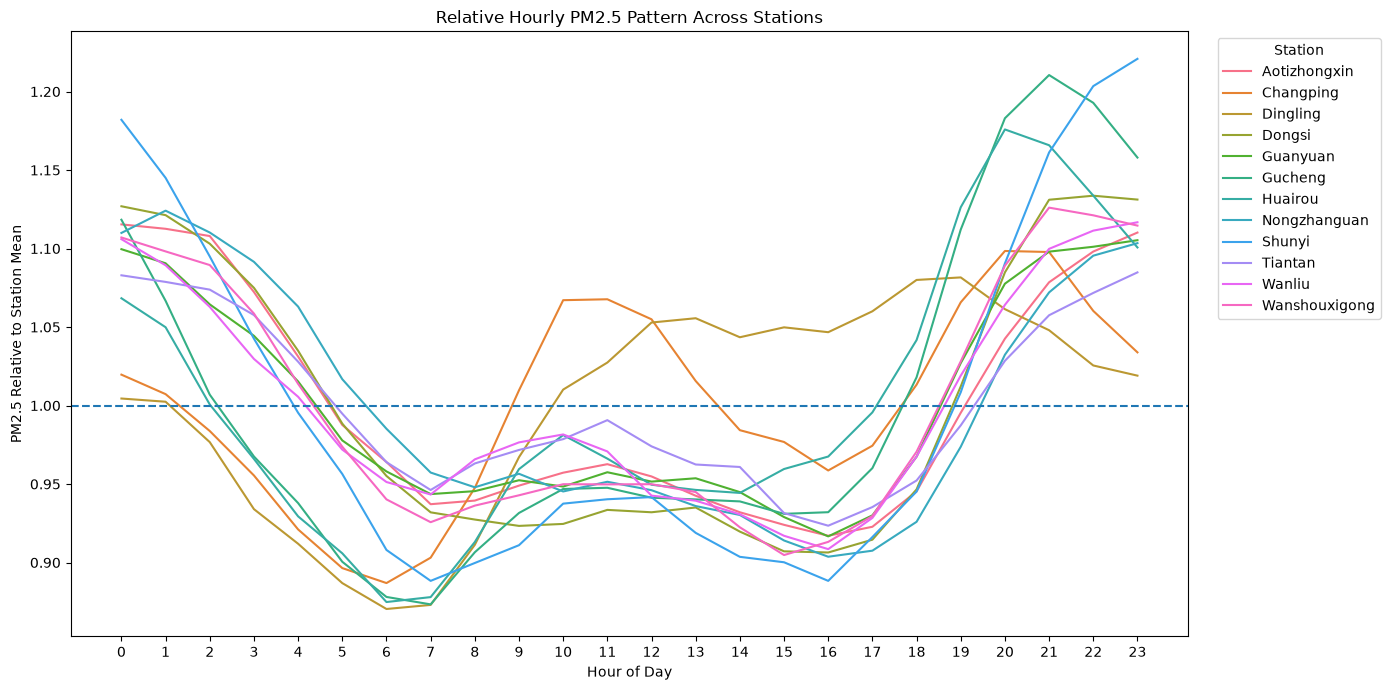

In [70]:
hourly_station_normalized = hourly_station_pm25.copy()

station_means = (
    hourly_station_normalized
    .groupby("station")["pm25"]
    .transform("mean")
)

hourly_station_normalized["relative_pm25"] = (
    hourly_station_normalized["pm25"] / station_means
)

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=hourly_station_normalized,
    x="hour",
    y="relative_pm25",
    hue="station"
)

plt.axhline(1.0, linestyle="--")

plt.title("Relative Hourly PM2.5 Pattern Across Stations")
plt.xlabel("Hour of Day")
plt.ylabel("PM2.5 Relative to Station Mean")
plt.xticks(range(24))

plt.legend(
    title="Station",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

**Hour-of-Day Patterns**

The hourly aggregation reveals a clear daily temporal pattern in PM2.5 concentrations across the monitoring stations. Several stations, including Aotizhongxin, Dongsi, Guanyuan, Nongzhanguan, Shunyi, Tiantan, Wanliu, and Wanshouxigong, show relatively higher PM2.5 levels during the late evening and night, followed by lower concentrations during the daytime and afternoon.

However, the hourly pattern is not identical across all stations. Changping, Dingling, and Huairou show more pronounced increases during the late morning or afternoon, while Gucheng exhibits a particularly strong increase during the evening. This indicates that although daily temporal structure is common across the network, its magnitude and shape vary by station.

The presence of consistent hour-of-day variation suggests that time of day provides useful information for PM2.5 forecasting. This supports including hour-of-day as an explicit temporal feature in the forecasting model, potentially using cyclic encoding so that midnight and 23:00 remain close in the feature representation.

The hourly analysis therefore provides evidence for explicit daily temporal features, while also indicating that station-specific behavior should be retained rather than assuming an identical daily pattern across all stations.

##### Day-of-week pattern

In [71]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

df["day_of_week"] = pd.Categorical(
    df["datetime"].dt.day_name(),
    categories=day_order,
    ordered=True
)

weekly_pm25 = (
    df.groupby("day_of_week", observed=False)["pm25"]
       .agg(["mean", "median", "std", "count"])
       .reset_index()
)

display(weekly_pm25.round(2))

,day_of_week,mean,median,std,count
0,Monday,73.030,51.000,74.700,58805
1,Tuesday,77.060,55.000,78.870,58584
2,Wednesday,77.900,55.000,79.010,58372
3,Thursday,79.170,54.000,79.720,58618
4,Friday,83.190,57.000,83.950,59080
5,Saturday,87.480,59.000,87.880,59297
6,Sunday,80.610,54.000,80.080,59273


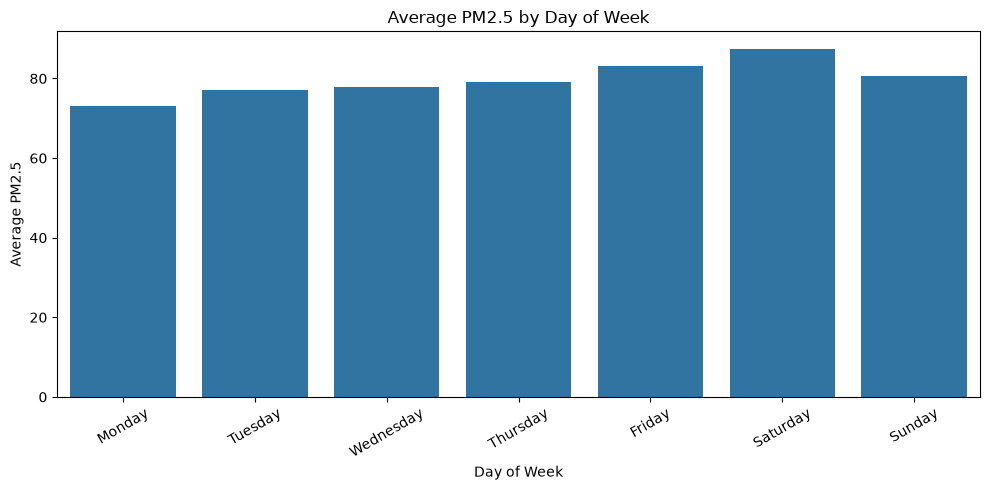

In [72]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=weekly_pm25,
    x="day_of_week",
    y="mean"
)

plt.title("Average PM2.5 by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average PM2.5")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [73]:
weekly_station_pm25 = (
    df.groupby(
        ["station", "day_of_week"],
        observed=False
    )["pm25"]
    .mean()
    .unstack()
)

display(weekly_station_pm25.round(2))

day_of_week,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
station,,,,,,,
Aotizhongxin,75.100,80.860,81.170,82.040,85.640,90.860,83.590
Changping,65.500,68.200,69.100,71.070,73.620,77.900,72.260
Dingling,61.190,63.650,63.600,65.390,68.190,72.360,67.310
Dongsi,78.430,83.710,83.310,84.040,91.150,95.190,87.320
Guanyuan,75.260,79.930,80.770,82.400,87.540,91.140,83.470
Gucheng,76.430,81.350,83.060,83.250,86.800,91.650,84.330
Huairou,64.640,65.170,67.820,71.470,72.300,73.860,72.040
Nongzhanguan,76.360,82.630,82.660,82.920,88.670,94.830,85.770
Shunyi,72.820,76.090,78.160,80.380,82.400,86.050,80.430


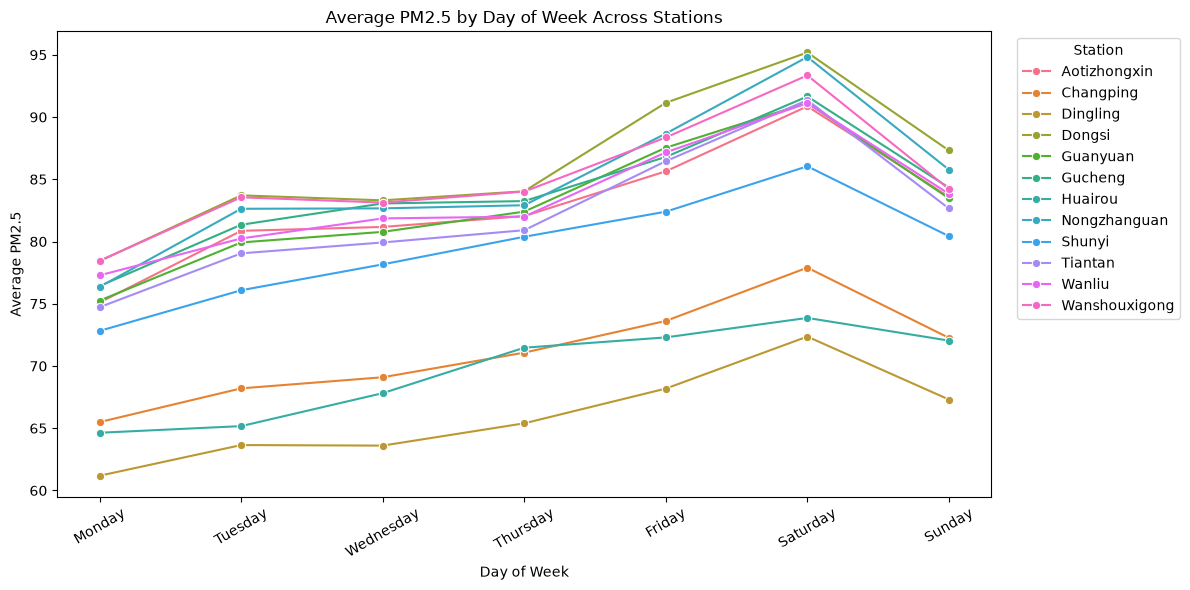

In [74]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=(
        df.groupby(
            ["station", "day_of_week"],
            observed=False
        )["pm25"]
        .mean()
        .reset_index()
    ),
    x="day_of_week",
    y="pm25",
    hue="station",
    marker="o"
)

plt.title("Average PM2.5 by Day of Week Across Stations")
plt.xlabel("Day of Week")
plt.ylabel("Average PM2.5")
plt.xticks(rotation=30)

plt.legend(
    title="Station",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

**Day-of-Week Patterns**

The day-of-week analysis shows a consistent weekly pattern in PM2.5 concentrations across all 12 monitoring stations.

Saturday has the highest average PM2.5 concentration at every station, while Monday has the lowest average concentration at every station. For most stations, PM2.5 gradually increases from Monday through Friday and reaches its highest level on Saturday, followed by a decrease on Sunday.

This pattern is consistent across stations, although the absolute PM2.5 concentrations differ between locations.

The results indicate that day of week contains useful temporal information for PM2.5 forecasting. However, the observed differences should be interpreted as associations rather than evidence that the day of week itself causes changes in PM2.5 concentrations.

The weekly pattern therefore provides motivation for including day-of-week information as an explicit temporal feature in the forecasting model.

##### Month-of-year

In [75]:
monthly_pm25 = (
    df.groupby("month")["pm25"]
       .agg(["mean", "median", "std", "count"])
       .reset_index()
)

display(monthly_pm25.round(2))

,month,mean,median,std,count
0,1,93.670,62.000,101.690,35300
1,2,87.570,45.000,101.850,31856
2,3,94.660,70.000,88.600,35293
3,4,72.730,61.000,56.440,33700
4,5,63.110,50.000,50.500,34712
5,6,69.090,53.000,58.860,33740
6,7,71.740,59.000,53.610,34716
7,8,53.470,41.000,42.600,35215
8,9,61.480,46.000,53.970,33724
9,10,91.730,57.000,90.370,34839


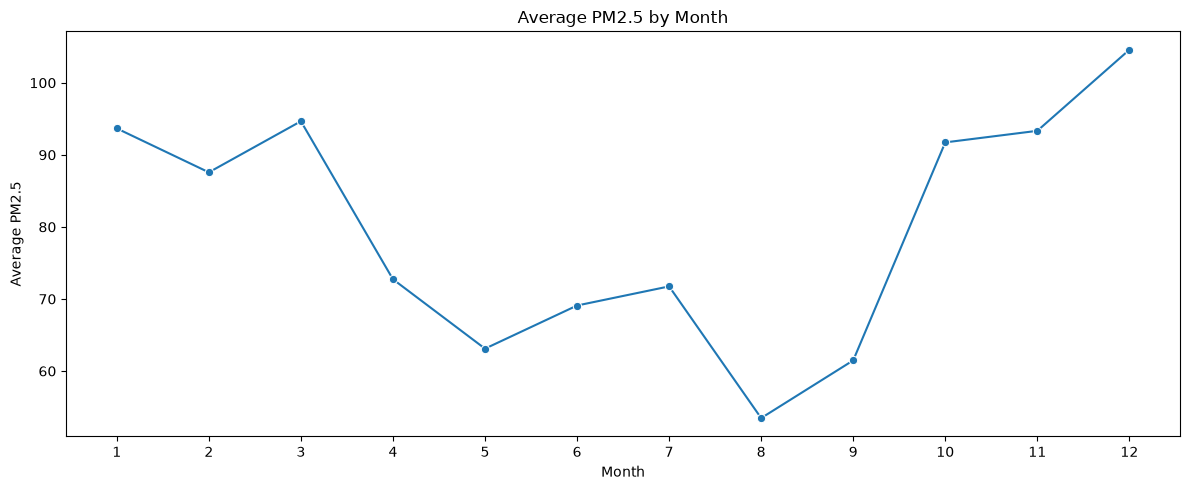

In [76]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_pm25,
    x="month",
    y="mean",
    marker="o"
)

plt.title("Average PM2.5 by Month")
plt.xlabel("Month")
plt.ylabel("Average PM2.5")
plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

In [77]:
month_order = list(range(1, 13))
monthly_station_pm25 = (
    df.groupby(["station", "month"])["pm25"]
       .mean()
       .unstack()
       .reindex(columns=month_order)
)

display(monthly_station_pm25.round(2))

month,1,2,3,4,5,6,7,8,9,10,11,12
station,,,,,,,,,,,,
Aotizhongxin,92.820,85.840,100.000,76.180,67.340,71.820,75.260,55.640,64.460,96.390,98.540,111.320
Changping,84.160,79.900,84.160,69.520,60.280,60.050,63.650,46.740,55.770,83.150,78.580,87.530
Dingling,73.160,78.150,84.100,64.760,53.700,56.470,59.810,43.490,49.930,80.310,69.900,78.820
Dongsi,100.510,93.920,100.530,77.080,70.030,73.310,80.190,58.640,67.230,98.770,99.910,113.130
Guanyuan,93.650,87.320,94.420,74.150,64.240,73.710,75.640,58.530,65.530,96.990,99.220,110.390
Gucheng,100.550,89.830,98.740,75.920,67.220,72.760,71.670,54.620,65.660,97.740,100.600,110.320
Huairou,78.700,80.720,89.440,67.250,54.980,56.110,67.050,47.580,54.610,79.360,76.710,81.490
Nongzhanguan,101.840,92.350,98.670,72.960,63.910,72.480,71.410,54.990,64.970,101.100,105.800,117.830
Shunyi,95.290,90.710,97.380,73.660,63.230,70.760,74.030,53.290,60.190,87.970,89.820,96.560


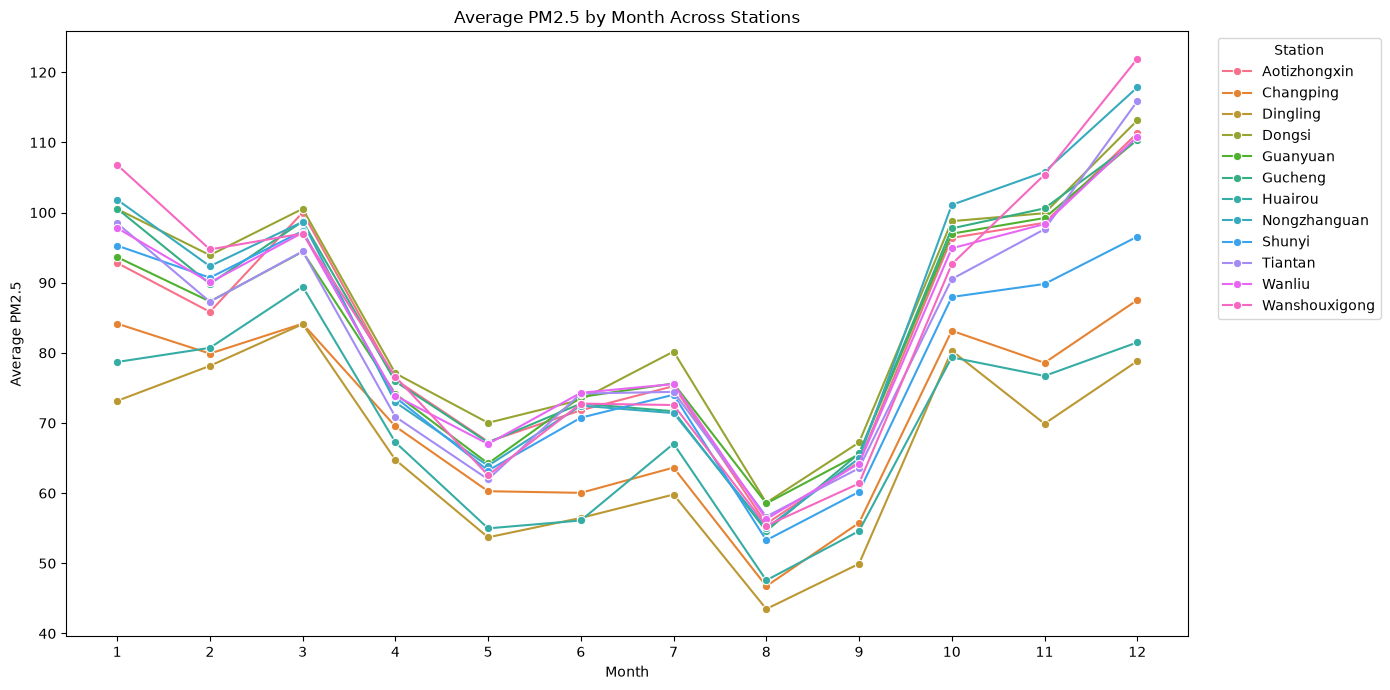

In [78]:
plt.figure(figsize=(14, 7))

sns.lineplot(
    data=(
        df.groupby(["station", "month"])["pm25"]
           .mean()
           .reset_index()
    ),
    x="month",
    y="pm25",
    hue="station",
    marker="o"
)

plt.title("Average PM2.5 by Month Across Stations")
plt.xlabel("Month")
plt.ylabel("Average PM2.5")
plt.xticks(range(1, 13))

plt.legend(
    title="Station",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

**Month-of-Year Patterns**

The monthly aggregation reveals a strong seasonal pattern in PM2.5 concentrations across all 12 monitoring stations.

PM2.5 concentrations are generally higher during the colder months, particularly October through March, with December showing the highest average concentration at most stations. In contrast, concentrations are generally lower from May through September, with August showing particularly low values across the monitoring network.

Although the absolute PM2.5 concentrations differ between stations, the broad seasonal pattern is consistent across locations. This indicates that month of year contains useful temporal information for PM2.5 forecasting.

The seasonal pattern supports including month-of-year as an explicit temporal feature in the forecasting model. Because months form a natural cycle, cyclic encoding can be considered during feature engineering so that adjacent months such as December and January are represented as temporally close.

**Phase B Summary: Temporal Dynamics and Seasonality**

The temporal analysis shows that PM2.5 has strong and consistent temporal structure across the 12 monitoring stations.

The ACF analysis shows very strong short-term persistence, with one-hour autocorrelation above 0.93 at every station. Autocorrelation remains meaningful at 24 hours but becomes weak by 48 hours. The PACF is dominated by the first lag, indicating that recent observations contain substantial information about the current PM2.5 level. These results provide statistical support for considering shorter look-back windows, particularly 24 hours, while longer windows such as 48 and 72 hours should remain candidates for validation.

The hour-of-day analysis reveals a clear daily pattern, although the shape and magnitude vary between stations. This supports including time-of-day information as an explicit temporal feature.

The day-of-week analysis also shows a consistent weekly pattern. Saturday has the highest average PM2.5 concentration and Monday the lowest at all 12 stations, although the differences should be interpreted as associations rather than causal effects.

The monthly analysis reveals an even stronger seasonal pattern. PM2.5 concentrations are generally higher during the colder months and lower during the warmer months, with December among the highest-concentration months and August among the lowest.

Overall, the temporal analysis indicates that PM2.5 forecasting should account for short-term temporal dependence, daily patterns, weekly patterns, and seasonal variation. These temporal variables can later be incorporated through appropriate cyclic feature representations.

The analysis does not yet determine the final look-back window or feature set. These choices should be evaluated during model development using validation data.

## Spatial Correlation

In [79]:
pm25_station_matrix = (
    df.pivot_table(
        index="datetime",
        columns="station",
        values="pm25"
    )
    .sort_index()
)

display(pm25_station_matrix.head())

station,Aotizhongxin,Changping,Dingling,Dongsi,Guanyuan,Gucheng,Huairou,Nongzhanguan,Shunyi,Tiantan,Wanliu,Wanshouxigong
datetime,,,,,,,,,,,,
2013-03-01 00:00:00,4.000,3.000,4.000,9.000,4.000,6.000,7.000,5.000,3.000,6.000,8.000,9.000
2013-03-01 01:00:00,8.000,3.000,7.000,4.000,4.000,6.000,4.000,8.000,12.000,6.000,9.000,11.000
2013-03-01 02:00:00,7.000,3.000,5.000,7.000,3.000,5.000,4.000,3.000,14.000,6.000,3.000,8.000
2013-03-01 03:00:00,6.000,3.000,6.000,3.000,3.000,6.000,3.000,5.000,12.000,6.000,11.000,8.000
2013-03-01 04:00:00,3.000,3.000,5.000,3.000,3.000,5.000,3.000,5.000,12.000,5.000,3.000,8.000


In [80]:
print("Shape:", pm25_station_matrix.shape)
print("Stations:", pm25_station_matrix.columns.tolist())

Shape: (34983, 12)
Stations: ['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']


In [81]:
pm25_spatial_corr = pm25_station_matrix.corr()

display(pm25_spatial_corr.round(3))

station,Aotizhongxin,Changping,Dingling,Dongsi,Guanyuan,Gucheng,Huairou,Nongzhanguan,Shunyi,Tiantan,Wanliu,Wanshouxigong
station,,,,,,,,,,,,
Aotizhongxin,1.000,0.857,0.834,0.958,0.963,0.908,0.854,0.955,0.901,0.942,0.946,0.931
Changping,0.857,1.000,0.925,0.829,0.849,0.864,0.866,0.820,0.821,0.818,0.875,0.806
Dingling,0.834,0.925,1.000,0.805,0.829,0.844,0.865,0.795,0.810,0.790,0.847,0.778
Dongsi,0.958,0.829,0.805,1.000,0.969,0.903,0.836,0.964,0.892,0.964,0.933,0.953
Guanyuan,0.963,0.849,0.829,0.969,1.000,0.928,0.850,0.949,0.886,0.957,0.956,0.953
Gucheng,0.908,0.864,0.844,0.903,0.928,1.000,0.859,0.884,0.862,0.894,0.936,0.896
Huairou,0.854,0.866,0.865,0.836,0.850,0.859,1.000,0.823,0.901,0.823,0.855,0.813
Nongzhanguan,0.955,0.820,0.795,0.964,0.949,0.884,0.823,1.000,0.889,0.957,0.918,0.942
Shunyi,0.901,0.821,0.810,0.892,0.886,0.862,0.901,0.889,1.000,0.883,0.876,0.875


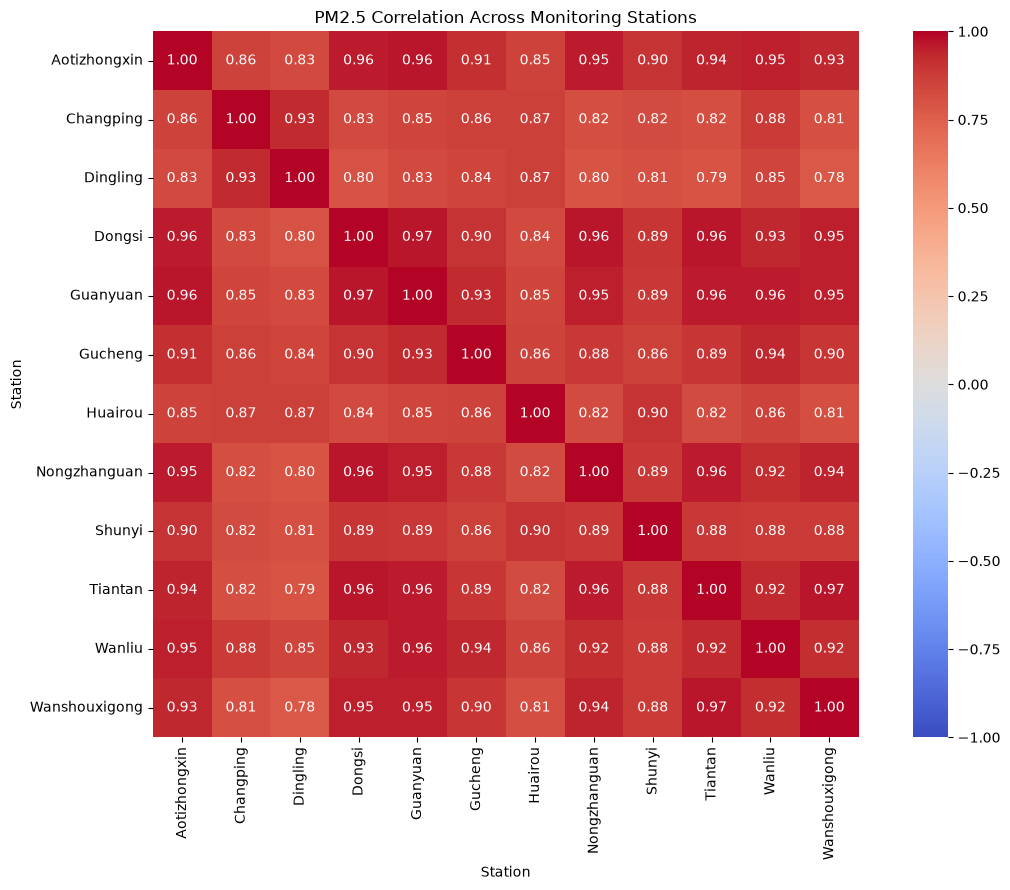

In [82]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    pm25_spatial_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)

plt.title("PM2.5 Correlation Across Monitoring Stations")
plt.xlabel("Station")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

In [83]:
corr_pairs = (
    pm25_spatial_corr
    .where(
        np.triu(
            np.ones(pm25_spatial_corr.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .sort_values(ascending=False)
)

display(corr_pairs.to_frame("correlation").round(3))
print("Strongest correlations:")
display(corr_pairs.head(10).round(3))

print("\nWeakest correlations:")
display(corr_pairs.tail(10).round(3))

correlation
station       station                   
Dongsi        Guanyuan             0.969
Tiantan       Wanshouxigong        0.967
Dongsi        Nongzhanguan         0.964
              Tiantan              0.964
Aotizhongxin  Guanyuan             0.963
...                                  ...
Wanshouxigong Nongzhanguan           NaN
              Shunyi                 NaN
              Tiantan                NaN
              Wanliu                 NaN
              Wanshouxigong          NaN

[144 rows x 1 columns]

Strongest correlations:


station       station      
Dongsi        Guanyuan        0.969
Tiantan       Wanshouxigong   0.967
Dongsi        Nongzhanguan    0.964
              Tiantan         0.964
Aotizhongxin  Guanyuan        0.963
              Dongsi          0.958
Guanyuan      Tiantan         0.957
Nongzhanguan  Tiantan         0.957
Guanyuan      Wanliu          0.956
Aotizhongxin  Nongzhanguan    0.955
dtype: float64


Weakest correlations:


station        station      
Wanshouxigong  Dingling        NaN
               Dongsi          NaN
               Guanyuan        NaN
               Gucheng         NaN
               Huairou         NaN
               Nongzhanguan    NaN
               Shunyi          NaN
               Tiantan         NaN
               Wanliu          NaN
               Wanshouxigong   NaN
dtype: float64

In [84]:
station_mean_corr = (
    pm25_spatial_corr
    .where(~np.eye(pm25_spatial_corr.shape[0], dtype=bool))
    .mean()
    .sort_values(ascending=False)
)

display(station_mean_corr.round(3))

station
Guanyuan        0.917
Aotizhongxin    0.914
Dongsi          0.910
Wanliu          0.908
Tiantan         0.902
Nongzhanguan    0.900
Wanshouxigong   0.894
Gucheng         0.889
Shunyi          0.872
Huairou         0.850
Changping       0.848
Dingling        0.829
dtype: float64

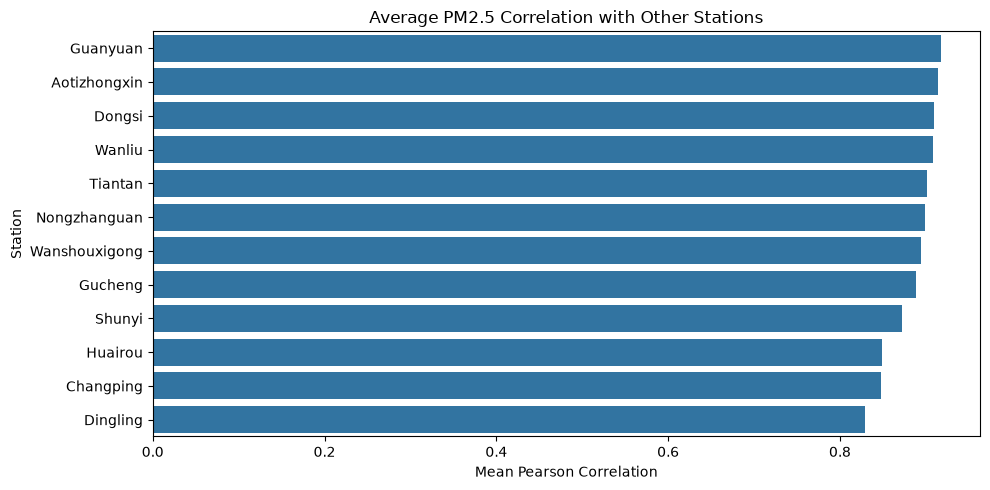

In [85]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=station_mean_corr.values,
    y=station_mean_corr.index
)

plt.title("Average PM2.5 Correlation with Other Stations")
plt.xlabel("Mean Pearson Correlation")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

**Spatial Correlation Findings**

The spatial correlation analysis shows a strong shared PM2.5 signal across the 12 monitoring stations. Pairwise Pearson correlations range from approximately 0.778 to 0.969, while the mean correlation of each station with all other stations ranges from 0.829 to 0.917.

This indicates that PM2.5 concentrations at different monitoring locations tend to vary together over time. However, the strength of the relationship is not identical across all stations. Guanyuan, Aotizhongxin, Dongsi, and Wanliu have the highest average correlations with the rest of the network, while Dingling, Changping, and Huairou show relatively more station-specific behavior.

The results provide evidence that information from other monitoring stations may be useful for PM2.5 forecasting. Therefore, multi-station information should be retained as a candidate feature set during model development.

The correlation analysis does not by itself establish that a multi-station model will outperform station-specific models. This will be evaluated later using forecasting validation across the required 1- to 24-hour prediction horizons.

## Multivariate Feature Importance.

#### Overall correlation with PM2.5

In [86]:
predictor_variables = [
    "pm10",
    "so2",
    "no2",
    "co",
    "o3",
    "temp",
    "pres",
    "dewp",
    "rain",
    "wspm"
]

pm25_feature_corr = (
    df[["pm25"] + predictor_variables]
    .corr()["pm25"]
    .drop("pm25")
    .sort_values(ascending=False)
)

display(pm25_feature_corr.round(3))

pm10    0.884
co      0.790
no2     0.667
so2     0.482
dewp    0.115
pres    0.019
rain   -0.014
temp   -0.131
o3     -0.150
wspm   -0.272
Name: pm25, dtype: float64

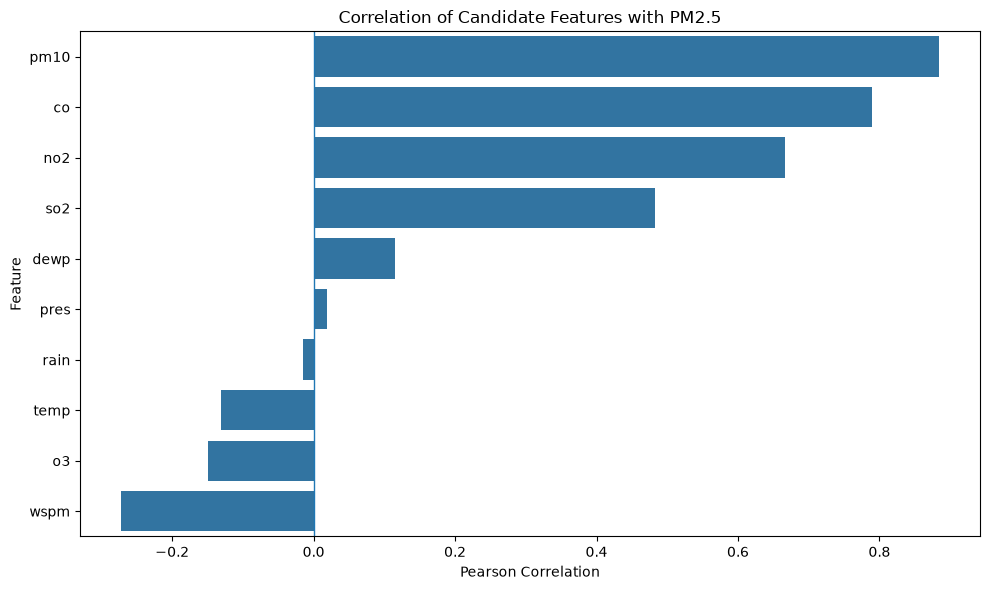

In [87]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=pm25_feature_corr.values,
    y=pm25_feature_corr.index
)

plt.title("Correlation of Candidate Features with PM2.5")
plt.xlabel("Pearson Correlation")
plt.ylabel("Feature")
plt.axvline(0, linewidth=1)

plt.tight_layout()
plt.show()

In [88]:
station_feature_corr = {}

for station, group in df.groupby("station"):
    station_feature_corr[station] = (
        group[["pm25"] + predictor_variables]
        .corr()["pm25"]
        .drop("pm25")
    )

station_feature_corr = pd.DataFrame(station_feature_corr).T

display(station_feature_corr.round(3))

,pm10,so2,no2,co,o3,temp,pres,dewp,rain,wspm
Aotizhongxin,0.879,0.481,0.685,0.785,-0.161,-0.129,-0.006,0.120,-0.014,-0.279
Changping,0.864,0.457,0.674,0.767,-0.098,-0.110,0.007,0.118,-0.009,-0.273
Dingling,0.868,0.475,0.718,0.803,-0.101,-0.090,-0.008,0.135,-0.009,-0.256
Dongsi,0.890,0.547,0.693,0.802,-0.138,-0.139,-0.006,0.129,-0.019,-0.302
Guanyuan,0.895,0.493,0.692,0.799,-0.141,-0.128,-0.005,0.125,-0.011,-0.284
Gucheng,0.855,0.459,0.695,0.768,-0.187,-0.144,0.020,0.099,-0.019,-0.252
Huairou,0.883,0.410,0.655,0.802,-0.064,-0.080,-0.003,0.121,-0.013,-0.220
Nongzhanguan,0.904,0.533,0.690,0.814,-0.189,-0.173,0.028,0.098,-0.022,-0.301
Shunyi,0.900,0.462,0.644,0.782,-0.135,-0.116,-0.002,0.125,-0.007,-0.271
Tiantan,0.893,0.397,0.663,0.800,-0.167,-0.152,0.007,0.112,-0.015,-0.291


In [89]:
candidate_features = [
    "pm25",
    "pm10",
    "so2",
    "no2",
    "co",
    "o3",
    "temp",
    "pres",
    "dewp",
    "rain",
    "wspm"
]

feature_corr = df[candidate_features].corr()

display(feature_corr.round(3))

,pm25,pm10,so2,no2,co,o3,temp,pres,dewp,rain,wspm
pm25,1.000,0.884,0.482,0.667,0.790,-0.150,-0.131,0.019,0.115,-0.014,-0.272
pm10,0.884,1.000,0.463,0.652,0.702,-0.111,-0.096,-0.018,0.070,-0.027,-0.184
so2,0.482,0.463,1.000,0.499,0.536,-0.165,-0.322,0.223,-0.267,-0.040,-0.109
no2,0.667,0.652,0.499,1.000,0.705,-0.472,-0.278,0.174,-0.032,-0.044,-0.400
co,0.790,0.702,0.536,0.705,1.000,-0.313,-0.326,0.188,-0.057,-0.013,-0.298
o3,-0.150,-0.111,-0.165,-0.472,-0.313,1.000,0.595,-0.446,0.312,0.023,0.296
temp,-0.131,-0.096,-0.322,-0.278,-0.326,0.595,1.000,-0.813,0.820,0.038,0.033
pres,0.019,-0.018,0.223,0.174,0.188,-0.446,-0.813,1.000,-0.750,-0.061,0.065
dewp,0.115,0.070,-0.267,-0.032,-0.057,0.312,0.820,-0.750,1.000,0.086,-0.297
rain,-0.014,-0.027,-0.040,-0.044,-0.013,0.023,0.038,-0.061,0.086,1.000,0.021


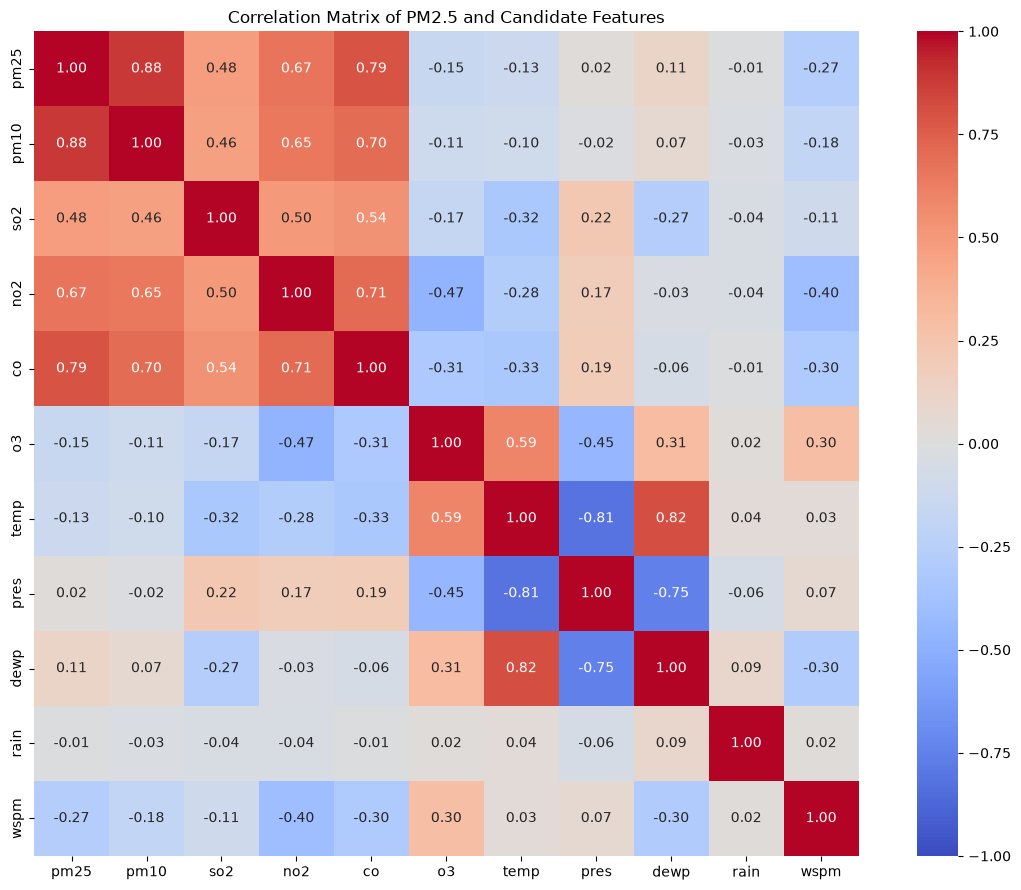

In [90]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    feature_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)

plt.title("Correlation Matrix of PM2.5 and Candidate Features")
plt.tight_layout()
plt.show()

**Feature Correlation Findings**

The correlation analysis shows that several pollutant variables have strong contemporaneous relationships with PM2.5. PM10 has the strongest correlation with PM2.5 (0.884), followed by CO (0.790), NO2 (0.667), and SO2 (0.482). These variables are therefore strong candidates for inclusion as input features in the forecasting model.

Wind speed (WSPM) has a moderate negative correlation with PM2.5 (-0.272), while ozone, temperature, and dew point show relatively weak linear relationships. Pressure and rainfall have correlations close to zero with PM2.5.

The predictor variables also show substantial correlations with each other. For example, PM10 is correlated with CO (0.702) and NO2 (0.652), while temperature, pressure, and dew point also show strong relationships with one another. This indicates that some candidate predictors contain overlapping information.

These correlations should not be interpreted as feature-importance scores. Pearson correlation only measures linear association at the same timestamp and does not capture lagged, nonlinear, or interaction effects that may be useful for sequence forecasting.

Therefore, the correlated variables will initially be retained as candidate features rather than removed based solely on correlation. Their usefulness can be evaluated later through model validation and feature-ablation experiments.

Rainfall is also retained despite its near-zero contemporaneous correlation with PM2.5 because its effect may be delayed or nonlinear.

Wind direction is treated separately because it is represented categorically in the dataset and requires an appropriate encoding before it can be incorporated into the sequence model.

**Summary: Multivariate Feature Relationships**

The multivariate correlation analysis indicates that PM2.5 is strongly associated with several pollutant measurements, particularly PM10, CO, NO2, and SO2. Meteorological variables generally show weaker contemporaneous linear relationships with PM2.5, although wind speed has a moderate negative association.

Several predictors are also correlated with one another, indicating that some information is shared between pollutant and meteorological variables. However, correlation alone does not determine whether a variable will improve a sequence forecasting model, since lagged and nonlinear relationships may also contribute predictive information.

Therefore, the identified variables will be retained as candidate inputs for model development. Feature usefulness and potential redundancy will be evaluated later through forecasting validation and feature-ablation experiments.

Combined with the temporal and spatial analyses, the EDA provides evidence that PM2.5 forecasting should consider historical pollutant values, meteorological conditions, temporal patterns, and potentially information from other monitoring stations.

## EDA Conclusions and Preprocessing Decisions

The EDA provides several important conclusions that will guide the preprocessing and forecasting pipeline.

### Forecasting Objective

PM2.5 is selected as the forecasting target. The model will use historical observations up to time `t` to predict PM2.5 for the next 24 hours, from `t+1` through `t+24`.

This is therefore formulated as a multi-step forecasting problem with a fixed 24-hour forecast horizon.

### Missing-Data Strategy

The missingness analysis shows that most missing runs are short, but rare long gaps are also present, particularly among pollutant variables. Therefore, a single interpolation strategy will not be applied to all missing values.

Short-gap temporal interpolation will be investigated using different thresholds, initially considering gaps of up to 3 hours and up to 6 hours. Long gaps will remain missing and will act as boundaries when constructing continuous sequences.

No interpolation strategy will be allowed to create artificial future target values for validation or test evaluation. PM2.5 values used as future target labels must be observed.

### Look-Back Windows

The ACF and PACF analysis shows strong short-term temporal dependence in PM2.5, with meaningful autocorrelation extending to approximately 24 hours and substantially weaker dependence at 48 and 72 hours.

Therefore, 24, 48, and 72 hours will be retained as candidate look-back windows. ACF and PACF provide statistical guidance for these candidates, while final selection will be based on forecasting validation.

### Candidate Input Features

The initial candidate numerical features are:

- PM2.5
- PM10
- SO2
- NO2
- CO
- O3
- Temperature
- Pressure
- Dew point
- Rainfall
- Wind speed

The correlation analysis indicates particularly strong contemporaneous relationships between PM2.5 and PM10, CO, NO2, and SO2. However, weak Pearson correlation does not imply that a variable has no predictive value because lagged and nonlinear relationships may still be useful. Therefore, candidate features will initially be retained and evaluated during model development.

### Temporal Features

The temporal analysis identified clear daily, weekly, and seasonal patterns in PM2.5. Temporal features will therefore be engineered from the timestamp.

Cyclic representations will be considered for hour of day, day of week, and month of year so that the cyclical nature of these variables is preserved.

### Wind Direction

Wind direction is stored as a categorical compass-direction variable rather than a numerical angle. It will therefore be handled separately from the continuous meteorological variables and transformed into an appropriate representation before model training.

### Spatial Information

PM2.5 concentrations show strong correlations between monitoring stations, with pairwise correlations ranging approximately from 0.778 to 0.969. This indicates a substantial shared spatial-temporal signal across the monitoring network.

Information from other stations will therefore remain a candidate input for a global or multi-station forecasting model. However, correlation alone does not establish that a multi-station model will outperform station-specific models, so this will be evaluated during model validation.

### Scaling

Numerical features will be scaled before training the neural network. Scaling parameters will be learned using only the training data and then applied to the validation and test sets to prevent information leakage.

### Sequence Construction

After missing-data treatment, feature engineering, and scaling, the data will be converted into overlapping input-output sequences.

For a look-back of `L` hours and a forecast horizon of 24 hours, each sample will contain:

- Input: the previous `L` hours of features
- Target: PM2.5 for the following 24 hours

The resulting input structure will have the form:

`(samples, lookback, features)`

while the target will contain 24 future PM2.5 values for each sample.

### Leakage Prevention

Only information available up to the forecasting time `t` will be used as model input. Future PM2.5 observations will not be used as input features, and future target values will remain observed-only for validation and test evaluation.

These decisions establish the preprocessing framework for the subsequent feature engineering, data preparation, and sequence construction stages.

# Preprocessing

### Train, Validation, and Test Split

Since this is a time-series forecasting problem, the dataset will be divided chronologically rather than randomly.

The model will be trained using earlier observations, while later observations will be reserved for validation and final testing. This prevents information from future periods from being used during model training.

The split will be performed independently along the time axis while retaining all monitoring stations within each period.

The validation set will be used for model selection and hyperparameter decisions, including the choice of look-back window and missing-data strategy.

The test set will remain untouched until the final model has been selected and will be used only for the final performance evaluation.

The split will therefore follow the temporal order:

Training period → Validation period → Test period

In [91]:
print("Overall date range:")
print("Start:", df["datetime"].min())
print("End:  ", df["datetime"].max())

print("\nNumber of observations by year:")
display(
    df.groupby(df["datetime"].dt.year)
       .size()
       .rename("observations")
       .to_frame()
)

Overall date range:
Start: 2013-03-01 00:00:00
End:   2017-02-28 23:00:00

Number of observations by year:


,observations
datetime,
2013,88128
2014,105120
2015,105120
2016,105408
2017,16992


In [92]:
train_end = "2015-12-31 23:00:00"
val_end = "2016-06-30 23:00:00"

In [93]:
train = df[df["datetime"] <= train_end].copy()

validation = df[
    (df["datetime"] > train_end) &
    (df["datetime"] <= val_end)
].copy()

test = df[
    df["datetime"] > val_end
].copy()

In [94]:
print("Training:")
print(train["datetime"].min(), "→", train["datetime"].max())
print("Rows:", len(train))

print("\nValidation:")
print(validation["datetime"].min(), "→", validation["datetime"].max())
print("Rows:", len(validation))

print("\nTest:")
print(test["datetime"].min(), "→", test["datetime"].max())
print("Rows:", len(test))

Training:
2013-03-01 00:00:00 → 2015-12-31 23:00:00
Rows: 298368

Validation:
2016-01-01 00:00:00 → 2016-06-30 23:00:00
Rows: 52416

Test:
2016-07-01 00:00:00 → 2017-02-28 23:00:00
Rows: 69984


In [95]:
for name, df in [
    ("Training", train),
    ("Validation", validation),
    ("Test", test)
]:
    print(f"{name}:")
    print("Stations:", df["station"].nunique())
    print(sorted(df["station"].unique()))
    print()

Training:
Stations: 12
['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']

Validation:
Stations: 12
['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']

Test:
Stations: 12
['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']



In [96]:
station_counts = pd.DataFrame({
    "train": train.groupby("station").size(),
    "validation": validation.groupby("station").size(),
    "test": test.groupby("station").size()
})

display(station_counts)

,train,validation,test
station,,,
Aotizhongxin,24864,4368,5832
Changping,24864,4368,5832
Dingling,24864,4368,5832
Dongsi,24864,4368,5832
Guanyuan,24864,4368,5832
Gucheng,24864,4368,5832
Huairou,24864,4368,5832
Nongzhanguan,24864,4368,5832
Shunyi,24864,4368,5832


In [97]:
print("Last training timestamp:   ", train["datetime"].max())
print("First validation timestamp:", validation["datetime"].min())
print("Last validation timestamp: ", validation["datetime"].max())
print("First test timestamp:      ", test["datetime"].min())

Last training timestamp:    2015-12-31 23:00:00
First validation timestamp: 2016-01-01 00:00:00
Last validation timestamp:  2016-06-30 23:00:00
First test timestamp:       2016-07-01 00:00:00


### Missing-data treatment

Checking missingness in each split

In [98]:
continuous_features = [
    "pm25",
    "pm10",
    "so2",
    "no2",
    "co",
    "o3",
    "temp",
    "pres",
    "dewp",
    "rain",
    "wspm"
]

In [99]:
split_missingness = pd.DataFrame({
    "train": train[continuous_features].isna().mean() * 100,
    "validation": validation[continuous_features].isna().mean() * 100,
    "test": test[continuous_features].isna().mean() * 100
})

display(split_missingness.round(3))

,train,validation,test
pm25,2.084,2.047,2.069
pm10,1.507,1.622,1.578
so2,2.295,1.723,1.813
no2,3.180,2.135,2.158
co,6.017,1.784,2.589
o3,3.346,2.196,3.061
temp,0.060,0.000,0.313
pres,0.060,0.000,0.304
dewp,0.062,0.000,0.313
rain,0.059,0.000,0.306


Implement the interpolate function

In [100]:
def interpolate_short_gaps(df, columns, max_gap):
    result = df.copy()

    result = result.sort_values(
        ["station", "datetime"]
    ).copy()

    for column in columns:
        result[column] = (
            result.groupby("station")[column]
                   .transform(
                       lambda s: s.interpolate(
                           method="linear",
                           limit=max_gap,
                           limit_area="inside"
                       )
                   )
        )

    return result

In [101]:
train_no_interp = train.copy()
val_no_interp = validation.copy()
test_no_interp = test.copy()

train_interp_3 = interpolate_short_gaps(
    train,
    continuous_features,
    max_gap=3
)

val_interp_3 = interpolate_short_gaps(
    validation,
    continuous_features,
    max_gap=3
)

test_interp_3 = interpolate_short_gaps(
    test,
    continuous_features,
    max_gap=3
)

train_interp_6 = interpolate_short_gaps(
    train,
    continuous_features,
    max_gap=6
)

val_interp_6 = interpolate_short_gaps(
    validation,
    continuous_features,
    max_gap=6
)

test_interp_6 = interpolate_short_gaps(
    test,
    continuous_features,
    max_gap=6
)

In [102]:
def compare_missingness(datasets, columns):
    rows = []

    for name, df in datasets.items():
        missing_pct = df[columns].isna().mean() * 100

        for column in columns:
            rows.append({
                "strategy": name,
                "variable": column,
                "missing_percentage": missing_pct[column]
            })

    return pd.DataFrame(rows)


missingness_comparison = compare_missingness(
    {
        "No interpolation": train_no_interp,
        "Interpolation <=3h": train_interp_3,
        "Interpolation <=6h": train_interp_6
    },
    continuous_features
)

missingness_comparison_pivot = missingness_comparison.pivot(
    index="variable",
    columns="strategy",
    values="missing_percentage"
)

display(missingness_comparison_pivot.round(3))

strategy,Interpolation <=3h,Interpolation <=6h,No interpolation
variable,,,
co,4.154,3.725,6.017
dewp,0.001,0.000,0.062
no2,1.894,1.619,3.180
o3,1.760,1.393,3.346
pm10,0.755,0.598,1.507
pm25,1.079,0.874,2.084
pres,0.001,0.000,0.060
rain,0.000,0.000,0.059
so2,1.311,1.096,2.295


In [103]:
for name, df in {
    "Validation - No interpolation": val_no_interp,
    "Validation - <=3h": val_interp_3,
    "Validation - <=6h": val_interp_6,
    "Test - No interpolation": test_no_interp,
    "Test - <=3h": test_interp_3,
    "Test - <=6h": test_interp_6
}.items():
    print(f"\n{name}")
    display(
        (df[continuous_features].isna().mean() * 100)
        .round(3)
        .to_frame("missing_percentage")
    )


Validation - No interpolation


,missing_percentage
pm25,2.047
pm10,1.622
so2,1.723
no2,2.135
co,1.784
o3,2.196
temp,0.000
pres,0.000
dewp,0.000
rain,0.000



Validation - <=3h


,missing_percentage
pm25,0.618
pm10,0.424
so2,0.620
no2,0.778
co,0.532
o3,0.584
temp,0.000
pres,0.000
dewp,0.000
rain,0.000



Validation - <=6h


...

,missing_percentage
pm25,2.069
pm10,1.578
so2,1.813
no2,2.158
co,2.589
o3,3.061
temp,0.313
pres,0.304
dewp,0.313
rain,0.306



Test - <=3h


,missing_percentage
pm25,0.934
pm10,0.654
so2,0.703
no2,0.740
co,1.182
o3,1.636
temp,0.109
pres,0.103
dewp,0.109
rain,0.103



Test - <=6h


,missing_percentage
pm25,0.732
pm10,0.492
so2,0.516
no2,0.534
co,0.945
o3,1.479
temp,0.000
pres,0.000
dewp,0.000
rain,0.000


**Missing-Data Preprocessing Decision**

The missingness analysis shows that most missing runs are short, while a small number of substantially longer gaps occur in the pollutant variables. Temporal interpolation was therefore evaluated using maximum gap lengths of 3 and 6 hours.

Interpolating gaps of up to 3 hours substantially reduces the remaining missingness. For example, training-set PM2.5 missingness decreases from 2.084% without interpolation to 1.079% after interpolation of gaps up to 3 hours. Increasing the threshold to 6 hours reduces it further to 0.874%, but the additional reduction is comparatively smaller.

Based on this trade-off, interpolation of gaps up to 3 hours will be used as the primary missing-data strategy. Gaps longer than 3 hours will remain missing and will be treated as boundaries when constructing continuous sequences.

The 6-hour interpolation strategy will be retained as a sensitivity experiment during model development to determine whether allowing longer interpolated gaps provides a meaningful improvement in forecasting performance.

Interpolation will be performed independently within each station and variable using chronological observations. No values will be interpolated across station boundaries or across the train, validation, and test split boundaries.

### Imputation

In [104]:
print("dtype:", df["wind_direction"].dtype)
print("\nUnique values:")
print(df["wind_direction"].dropna().unique())

print("\nValue counts:")
display(df["wind_direction"].value_counts(dropna=False))

dtype: str

Unique values:
<StringArray>
[  'E', 'ENE',  'NE', 'NNE',   'N',  'SE', 'WNW',   'S', 'SSW',  'SW', 'WSW',
 'ESE', 'SSE',   'W', 'NNW',  'NW']
Length: 16, dtype: str

Value counts:


wind_direction
NE     10573
NW      6831
NNE     5341
ENE     5337
SW      4897
NNW     4379
N       4357
E       4203
SE      3964
ESE     3696
SSW     3357
S       3120
SSE     2665
WNW     2477
WSW     2081
W       1622
NaN     1084
Name: count, dtype: int64

- Because rainfall is a discrete measurement, linear interpolation is not particularly meaningful. Its missingness is also extermely low. We leave missing rainfall values as NaN for now and let the sequence construction strategy handle the very small number of affected windows
- There are 16 compass directions which we will map to angles and create wind_direction_sin and wind_direction_cos. missing values will remain missing


In [105]:
continuous_features = [
    "pm25",
    "pm10",
    "so2",
    "no2",
    "co",
    "o3",
    "temp",
    "pres",
    "dewp",
    "wspm"
]

rain_feature = "rain"

wind_direction_feature = "wind_direction"

In [106]:
import numpy as np

wind_angles = {
    "N": 0,
    "NNE": 22.5,
    "NE": 45,
    "ENE": 67.5,
    "E": 90,
    "ESE": 112.5,
    "SE": 135,
    "SSE": 157.5,
    "S": 180,
    "SSW": 202.5,
    "SW": 225,
    "WSW": 247.5,
    "W": 270,
    "WNW": 292.5,
    "NW": 315,
    "NNW": 337.5
}

In [107]:
def add_wind_direction_features(df):
    result = df.copy()

    angle = result["wind_direction"].map(wind_angles)

    radians = np.deg2rad(angle)

    result["wind_direction_sin"] = np.sin(radians)
    result["wind_direction_cos"] = np.cos(radians)

    return result

In [108]:
def preprocess_split(df, interpolation_limit=3):
    result = df.copy()

    result = result.sort_values(
        ["station", "datetime"]
    ).copy()

    # Interpolate short gaps in continuous variables
    for column in continuous_features:
        result[column] = (
            result.groupby("station")[column]
            .transform(
                lambda s: s.interpolate(
                    method="linear",
                    limit=interpolation_limit,
                    limit_area="inside"
                )
            )
        )

    # Convert wind direction to cyclic features
    result = add_wind_direction_features(result)

    return result

In [109]:
train_processed = preprocess_split(train)
validation_processed = preprocess_split(validation)
test_processed = preprocess_split(test)

In [110]:
processed_features = (
    continuous_features
    + ["rain", "wind_direction_sin", "wind_direction_cos"]
)

for name, df in {
    "Train": train_processed,
    "Validation": validation_processed,
    "Test": test_processed
}.items():

    print(f"\n{name}")
    display(
        (df[processed_features].isna().mean() * 100)
        .round(3)
        .to_frame("missing_percentage")
    )


Train


,missing_percentage
pm25,1.079
pm10,0.755
so2,1.311
no2,1.894
co,4.154
o3,1.760
temp,0.001
pres,0.001
dewp,0.001
wspm,0.000



Validation


,missing_percentage
pm25,0.618
pm10,0.424
so2,0.620
no2,0.778
co,0.532
o3,0.584
temp,0.000
pres,0.000
dewp,0.000
wspm,0.000



Test


,missing_percentage
pm25,0.934
pm10,0.654
so2,0.703
no2,0.740
co,1.182
o3,1.636
temp,0.109
pres,0.103
dewp,0.109
wspm,0.069


In [111]:
model_input_features = [
    "pm25",
    "pm10",
    "so2",
    "no2",
    "co",
    "o3",
    "temp",
    "pres",
    "dewp",
    "rain",
    "wspm",
    "wind_direction_sin",
    "wind_direction_cos"
]

target_feature = "pm25"

lookback_candidates = [24, 48, 72]
forecast_horizon = 24

In [112]:
def sequence_availability(
    df,
    input_features,
    target_feature,
    lookback,
    horizon
):
    valid_sequences = 0
    total_sequences = 0

    for station, group in df.groupby("station"):
        group = group.sort_values("datetime").reset_index(drop=True)

        input_complete = (
            group[input_features]
            .notna()
            .all(axis=1)
        )

        target_complete = (
            group[target_feature]
            .notna()
        )

        # Rolling windows identify whether every timestep
        # in each required window is complete.
        input_windows = (
            input_complete
            .rolling(lookback)
            .sum()
            .eq(lookback)
        )

        target_windows = (
            target_complete
            .rolling(horizon)
            .sum()
            .eq(horizon)
        )

        n = len(group)

        total_sequences += max(
            0,
            n - lookback - horizon + 1
        )

        for target_end in range(
            lookback + horizon - 1,
            n
        ):
            input_end = target_end - horizon

            if (
                input_windows.iloc[input_end - 1]
                and target_windows.iloc[target_end]
            ):
                valid_sequences += 1

    return total_sequences, valid_sequences

In [113]:
sequence_results = []

for lookback in lookback_candidates:
    total, valid = sequence_availability(
        train_processed,
        model_input_features,
        target_feature,
        lookback,
        forecast_horizon
    )

    sequence_results.append({
        "lookback": lookback,
        "total_possible": total,
        "complete_sequences": valid,
        "percentage": 100 * valid / total
    })

sequence_results = pd.DataFrame(sequence_results)

display(sequence_results.round(3))

,lookback,total_possible,complete_sequences,percentage
0,24,297804,247599,83.142
1,48,297516,228610,76.840
2,72,297228,212459,71.480


We choose 24-hour lookback.


### Temporal feature engineering

We have three recurring temporal patterns from the EDA:

1. Hour of day: daily cycle
2. Day of week: weekly cycle
3. Month: annual/seasonal cycle


Because these are cyclic, we should not encode them as ordinary integers. For example, hour 23 and hour 0 are adjacent in time, but numerically 23 and 0 look very far apart. We will use sin and cosine for each cycle.


In [114]:
import numpy as np

def add_temporal_features(df):
    result = df.copy()

    # Hour of day: 0-23
    result["hour_sin"] = np.sin(2 * np.pi * result["hour"] / 24)
    result["hour_cos"] = np.cos(2 * np.pi * result["hour"] / 24)

    # Day of week: Monday=0, Sunday=6
    day_of_week = result["datetime"].dt.dayofweek
    result["dow_sin"] = np.sin(2 * np.pi * day_of_week / 7)
    result["dow_cos"] = np.cos(2 * np.pi * day_of_week / 7)

    # Month: 1-12
    result["month_sin"] = np.sin(2 * np.pi * (result["month"] - 1) / 12)
    result["month_cos"] = np.cos(2 * np.pi * (result["month"] - 1) / 12)

    return result

In [115]:
train_processed = add_temporal_features(train_processed)
validation_processed = add_temporal_features(validation_processed)
test_processed = add_temporal_features(test_processed)

In [116]:
# train_processed.head()

In [117]:
model_input_features = [
    "pm25", "pm10", "so2", "no2", "co", "o3",
    "temp", "pres", "dewp", "rain", "wspm",
    "wind_direction_sin", "wind_direction_cos"
]

In [118]:
model_input_features += [
    "hour_sin", "hour_cos",
    "dow_sin", "dow_cos",
    "month_sin", "month_cos"
]

**Temporal Feature Engineering**

The EDA identified recurring patterns at the hourly, weekly, and seasonal levels. These temporal variables are represented using cyclic sine and cosine transformations rather than as ordinary integer values.

Hour of day is encoded as a 24-hour cycle, day of week as a 7-day cycle, and month as a 12-month cycle. Using both sine and cosine preserves the position within each cycle while ensuring that adjacent periods, such as 23:00 and 00:00, remain close in the feature space.

These temporal features will be provided to the forecasting model alongside pollutant and meteorological variables.

One hot encoding the station for global model

In [119]:
station_columns = sorted(train_processed["station"].unique())

def add_station_one_hot(df, station_columns):
    result = df.copy()

    station_dummies = pd.get_dummies(
        result["station"],
        prefix="station",
        dtype=float
    )

    # Ensure every split has exactly the same station columns
    expected_columns = [f"station_{station}" for station in station_columns]

    station_dummies = station_dummies.reindex(
        columns=expected_columns,
        fill_value=0
    )

    return pd.concat(
        [result, station_dummies],
        axis=1
    )

In [120]:
train_processed = add_station_one_hot(
    train_processed,
    station_columns
)

validation_processed = add_station_one_hot(
    validation_processed,
    station_columns
)

test_processed = add_station_one_hot(
    test_processed,
    station_columns
)

In [121]:
station_feature_columns = [
    f"station_{station}"
    for station in station_columns
]

print(station_feature_columns)
print(len(station_feature_columns))

['station_Aotizhongxin', 'station_Changping', 'station_Dingling', 'station_Dongsi', 'station_Guanyuan', 'station_Gucheng', 'station_Huairou', 'station_Nongzhanguan', 'station_Shunyi', 'station_Tiantan', 'station_Wanliu', 'station_Wanshouxigong']
12


In [122]:
continuous_model_features = [
    "pm25", "pm10", "so2", "no2", "co", "o3",
    "temp", "pres", "dewp", "rain", "wspm",
    "wind_direction_sin", "wind_direction_cos",
    "hour_sin", "hour_cos",
    "dow_sin", "dow_cos",
    "month_sin", "month_cos"
]

station_feature_columns = [
    f"station_{station}"
    for station in station_columns
]

model_input_features = (
    continuous_model_features
    + station_feature_columns
)

target_feature = "pm25"

lookback = 24
forecast_horizon = 24

### Scaling

In [123]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [124]:
scaler.fit(
    train_processed[continuous_model_features]
)

StandardScaler()

In [125]:
train_processed[continuous_model_features] = (
    scaler.transform(
        train_processed[continuous_model_features]
    )
)

validation_processed[continuous_model_features] = (
    scaler.transform(
        validation_processed[continuous_model_features]
    )
)

test_processed[continuous_model_features] = (
    scaler.transform(
        test_processed[continuous_model_features]
    )
)

**Feature Scaling**

The continuous input features are standardized before sequence construction. The scaler is fitted exclusively on the training data to prevent information from the validation or test periods from influencing the transformation.

The same training-derived scaling parameters are then applied to the validation and test sets. Station one-hot features are not scaled because they are categorical binary indicators.

Remaining missing values from gaps longer than three hours are retained and will be used as sequence boundaries during supervised sequence construction.

### Sequence construction

* 24 hours of history
* 31 features per timestep
* 24 future PM2.5 values
* No unresolved missing values inside either window
* No sequence crossing a station boundary

In [126]:
import numpy as np

def create_sequences(
    df,
    input_features,
    target_feature,
    lookback=24,
    horizon=24
):
    X_sequences = []
    y_sequences = []

    for station, group in df.groupby("station"):
        group = group.sort_values("datetime").reset_index(drop=True)

        X_values = group[input_features].to_numpy(dtype=np.float32)
        y_values = group[target_feature].to_numpy(dtype=np.float32)

        n = len(group)

        for start in range(n - lookback - horizon + 1):
            input_end = start + lookback
            target_end = input_end + horizon

            X_window = X_values[start:input_end]
            y_window = y_values[input_end:target_end]

            # Discard sequences containing unresolved missing values
            if np.isnan(X_window).any():
                continue

            if np.isnan(y_window).any():
                continue

            X_sequences.append(X_window)
            y_sequences.append(y_window)

    return (
        np.asarray(X_sequences, dtype=np.float32),
        np.asarray(y_sequences, dtype=np.float32)
    )

In [127]:
X_train, y_train = create_sequences(
    train_processed,
    model_input_features,
    target_feature,
    lookback,
    forecast_horizon
)

X_validation, y_validation = create_sequences(
    validation_processed,
    model_input_features,
    target_feature,
    lookback,
    forecast_horizon
)

X_test, y_test = create_sequences(
    test_processed,
    model_input_features,
    target_feature,
    lookback,
    forecast_horizon
)

In [128]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (247773, 24, 31)
y_train: (247773, 24)
X_validation: (46607, 24, 31)
y_validation: (46607, 24)
X_test: (50199, 24, 31)
y_test: (50199, 24)


In [129]:
print("NaNs in X_train:", np.isnan(X_train).sum())
print("NaNs in y_train:", np.isnan(y_train).sum())

print("NaNs in X_validation:", np.isnan(X_validation).sum())
print("NaNs in y_validation:", np.isnan(y_validation).sum())

print("NaNs in X_test:", np.isnan(X_test).sum())
print("NaNs in y_test:", np.isnan(y_test).sum())

NaNs in X_train: 0
NaNs in y_train: 0
NaNs in X_validation: 0
NaNs in y_validation: 0
NaNs in X_test: 0
NaNs in y_test: 0


#### Saving files


In [135]:
from pathlib import Path


SEQUENCE_DIR = Path("sequences")
ARTIFACT_DIR = Path("artifacts")

SEQUENCE_DIR.mkdir(exist_ok=True)
ARTIFACT_DIR.mkdir(exist_ok=True)

In [136]:
np.savez_compressed(
    SEQUENCE_DIR / "train_sequences.npz",
    X=X_train,
    y=y_train
)

np.savez_compressed(
    SEQUENCE_DIR / "validation_sequences.npz",
    X=X_validation,
    y=y_validation
)

np.savez_compressed(
    SEQUENCE_DIR / "test_sequences.npz",
    X=X_test,
    y=y_test
)

In [138]:
import joblib

joblib.dump(
    scaler,
    ARTIFACT_DIR / "scaler.joblib"
)

['artifacts/scaler.joblib']

In [137]:
import json

feature_config = {
    "input_features": model_input_features,
    "continuous_features": continuous_model_features,
    "station_features": station_feature_columns,
    "target_feature": target_feature,
    "lookback": lookback,
    "forecast_horizon": forecast_horizon,
    "n_input_features": len(model_input_features),
    "n_stations": len(station_columns)
}

with open(ARTIFACT_DIR / "feature_config.json", "w") as f:
    json.dump(feature_config, f, indent=4)

In [ ]:
target_index = continuous_model_features.index(target_feature)

target_scaler = {
    "mean": float(scaler.mean_[target_index]),
    "std": float(scaler.scale_[target_index])
}

with open(ARTIFACT_DIR / "target_scaler.json", "w") as f:
    json.dump(target_scaler, f, indent=4)
